### NLP Airline Sentiment Classifier


##### Context

You have been provided with the Twitter US Airline Sentiment dataset, which contains ~14,640 tweets about various airlines. Each tweet is labeled with one of three sentiment classes:

- Negative
- Neutral
- Positive

The goal is to preprocess and explore the data, and then build a multi-layer feed-forward neural network (ANN) to classify tweets into these three sentiment classes. You will experiment with different vectorization techniques (e.g., TF-IDF, Word2Vec, or FastText) and incorporate various techniques to improve the model’s performance.

##### Loading Libraries

In [1]:
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
import emoji
import nltk
import spacy
import string
from nltk.corpus import stopwords
from collections import Counter
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model
from pyLDAvis import prepare
from scipy.sparse import issparse
from sklearn.preprocessing import normalize

#Vectorizations:
from gensim.models import Word2Vec 
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import FastText 

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA,TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

###### Expanding column width to see the full sentences in dataframes

In [2]:
pd.set_option('display.max_colwidth', None)

###### Muting Pandas Slice Warnings

In [3]:
pd.options.mode.chained_assignment = None

***

#### Loading Dataset

In [4]:
#Loading all the bbc news dataset from relevant csv file
df_tweets = pd.read_csv("../data/Tweets.csv")
#display(df_tweets.head(2))
#print(' ')
#display(df_tweets.sample(2))
#print(' ')
#display(df_tweets.tail(2))

full_df_tweets = df_tweets.copy()

#Updating list for our Columns for Dataframe 
full_df_tweets_columns = list(full_df_tweets)
#Cleaning Columns names in case they had any whitespace not visible
full_df_tweets.columns = full_df_tweets.columns.str.strip()
print(full_df_tweets_columns)

['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


#### Data Preprocessing & Exploratory Data Analysis (EDA)

In [5]:
# Initial shape of the DataFrame
print(f"DataFrame Initial Shape is: {full_df_tweets.shape}")
print(' ')

#Checking in the DataFrame for duplicates
print(f'DataFrame duplicate rows are: {full_df_tweets.duplicated().sum()}')
print(' ')

#Checking for duplicate rows being fixed
print('Current duplicate rows are:')
print(full_df_tweets.duplicated().sum())
print(' ')

#Reseting index of DataFrame
full_df_tweets.reset_index(drop=True,inplace=True)

#Dropping duplicate data rows found before in DataFrame 
print('Updated duplicate rows are:')
print(full_df_tweets.drop_duplicates(inplace=True))
print(' ')
print(f"DataFrame after cleaning duplicates Shape is: {full_df_tweets.shape}")
print(' ')

DataFrame Initial Shape is: (14640, 15)
 
DataFrame duplicate rows are: 36
 
Current duplicate rows are:
36
 
Updated duplicate rows are:
None
 
DataFrame after cleaning duplicates Shape is: (14604, 15)
 


In [6]:
#Initial shape of the DataFrame
print(f"DataFrame Current Shape is: {full_df_tweets.shape}")
print(' ')

print("Checking for missing values in DataFrame")
print(full_df_tweets.isna().sum())
print(' ')

DataFrame Current Shape is: (14604, 15)
 
Checking for missing values in DataFrame
tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5445
negativereason_confidence        4101
airline                             0
airline_sentiment_gold          14564
name                                0
negativereason_gold             14572
retweet_count                       0
text                                0
tweet_coord                     13589
tweet_created                       0
tweet_location                   4723
user_timezone                    4814
dtype: int64
 


In [7]:
#Creating a DataFrame of missing counts
many_null_value_cols_check = pd.DataFrame(full_df_tweets.isnull().sum().sort_values(ascending=False))
many_null_value_cols_check.columns = ['Missing_Count']

#Adding the Total Rows column
many_null_value_cols_check['Total_Rows'] = len(full_df_tweets)

#Adding the % Missing values column
many_null_value_cols_check['Missing_Percent'] = (many_null_value_cols_check['Missing_Count'] / len(full_df_tweets)) * 100

#Rounding the percentage to 2 decimal places for cleaner viewing
many_null_value_cols_check['Missing_Percent'] = many_null_value_cols_check['Missing_Percent'].round(2)

print(many_null_value_cols_check.head(15))

                              Missing_Count  Total_Rows  Missing_Percent
negativereason_gold                   14572       14604            99.78
airline_sentiment_gold                14564       14604            99.73
tweet_coord                           13589       14604            93.05
negativereason                         5445       14604            37.28
user_timezone                          4814       14604            32.96
tweet_location                         4723       14604            32.34
negativereason_confidence              4101       14604            28.08
airline                                   0       14604             0.00
tweet_id                                  0       14604             0.00
airline_sentiment                         0       14604             0.00
airline_sentiment_confidence              0       14604             0.00
text                                      0       14604             0.00
retweet_count                             0       1

In [8]:
#Dropping rows with many NaNs in Dataframe
#errors='ignore' to ensure that the code won't crash if columns are already deleted.

full_df_tweets = full_df_tweets.drop(columns=['negativereason_gold','airline_sentiment_gold','tweet_coord','user_timezone','tweet_location',
                                              'negativereason_confidence','tweet_id','name'], errors='ignore')

#Updating list for our Columns for Dataframe 
full_df_tweets_columns = list(full_df_tweets)
#Cleaning Columns names in case they had any whitespace not visible
full_df_tweets.columns = full_df_tweets.columns.str.strip()
print(full_df_tweets_columns)
print(' ')

print("Current shape:", full_df_tweets.shape)

['airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'airline', 'retweet_count', 'text', 'tweet_created']
 
Current shape: (14604, 7)


##### Column airline_sentiment

The unique values in Column airline_sentiment are: 3
 
airline_sentiment
negative    9159
neutral     3091
positive    2354
Name: count, dtype: int64
 


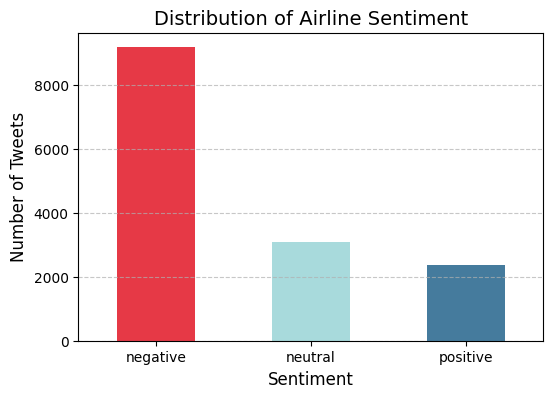

In [9]:
#Exploring Column airline_sentiment

#Understanding values in Column airline_sentiment
unique_airline_sentiment_count = full_df_tweets['airline_sentiment'].nunique()
print('The unique values in Column airline_sentiment are:',unique_airline_sentiment_count)
print(' ')

sentiment_counts = full_df_tweets['airline_sentiment'].value_counts()
#Sorting the counts in descending order
sentiment_counts = sentiment_counts.sort_values(ascending=False)
print(sentiment_counts)
print(' ')

#Plotting a bar chart for sentiment_counts
plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind='bar', color=['#E63946', '#A8DADC', '#457B9D'])

plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.title('Distribution of Airline Sentiment', fontsize=14)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

##### Column airline_sentiment_confidence

The unique values in Column airline_sentiment_confidence are: 1023
 
airline_sentiment_confidence
1.0000    10409
0.6667       71
0.6632       35
0.6596       30
0.6559       30
          ...  
0.6977        1
0.6928        1
0.7127        1
0.3684        1
0.6207        1
Name: count, Length: 1023, dtype: int64
 


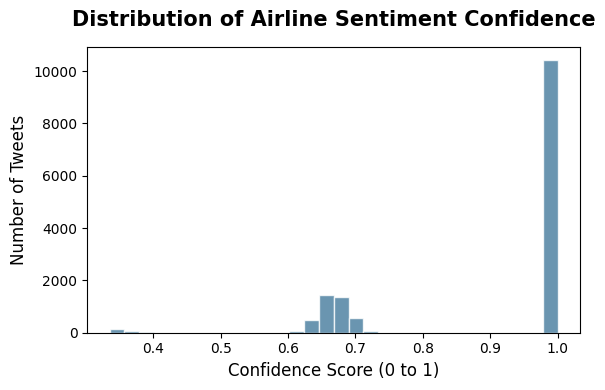

In [10]:
#Exploring Column airline_sentiment_confidence
#left skewed between 0 and 1

#Understanding values in Column airline_sentiment_confidence
unique_airline_sentiment_confidence_count = full_df_tweets['airline_sentiment_confidence'].nunique()
print('The unique values in Column airline_sentiment_confidence are:',unique_airline_sentiment_confidence_count)
print(' ')

sentiment_confidence_counts = full_df_tweets['airline_sentiment_confidence'].value_counts()
#Sorting the counts in descending order
sentiment_confidence_counts = sentiment_confidence_counts.sort_values(ascending=False)
print(sentiment_confidence_counts)
print(' ')

#Defining the data from the airline_sentiment_confidence column
airline_sentiment_confidence_data = full_df_tweets['airline_sentiment_confidence']

#Plotting a histogram
plt.figure(figsize=(6, 4))
plt.hist(airline_sentiment_confidence_data, bins=30, color='#457B9D', edgecolor='white', alpha=0.8)

plt.title('Distribution of Airline Sentiment Confidence', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Confidence Score (0 to 1)', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

plt.tight_layout()
plt.show()

##### Column negativereason

In [11]:
#Exploring Column negativereason

#Understanding values in Column negativereason
unique_negativereason_count = full_df_tweets['negativereason'].nunique()
print('The unique values in Column negativereason are:', unique_negativereason_count)
print(' ')

negativereason_counts = full_df_tweets['negativereason'].value_counts().sort_values(ascending=False)
#Sorting the counts in descending order
negativereason_counts = negativereason_counts.sort_values(ascending=False)
print('Initial values for negativereason counts:')
print(negativereason_counts)
print(' ')

#Creating a dictionary to map the current long names to new shorter names for plots
short_negativereason = {
    "Customer Service Issue": "Customer Service",
    "Late Flight": "Delay",
    "Can't Tell": "Unknown",
    "Cancelled Flight": "Cancellation",
    "Lost Luggage": "Lost Luggage",
    "Bad Flight": "Flight Quality",
    "Flight Booking Problems": "Booking",
    "Flight Attendant Complaints": "Attendant Complaint",
    "longlines": "Lines",
    "Damaged Luggage": "Damaged Luggage"
}

#Applying the mapping to column negativereason
full_df_tweets['negativereason'] = full_df_tweets['negativereason'].replace(short_negativereason)

#Verifying the changes in column negativereason values
print('Updated values for negativereason counts:')
print(full_df_tweets['negativereason'].value_counts())

The unique values in Column negativereason are: 10
 
Initial values for negativereason counts:
negativereason
Customer Service Issue         2904
Late Flight                    1660
Can't Tell                     1190
Cancelled Flight                843
Lost Luggage                    721
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     480
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64
 
Updated values for negativereason counts:
negativereason
Customer Service       2904
Delay                  1660
Unknown                1190
Cancellation            843
Lost Luggage            721
Flight Quality          580
Booking                 529
Attendant Complaint     480
Lines                   178
Damaged Luggage          74
Name: count, dtype: int64


negativereason
Customer Service       2904
Delay                  1660
Unknown                1190
Cancellation            843
Luggage Issue           795
Flight Quality          580
Booking                 529
Attendant Complaint     480
Lines                   178
Name: count, dtype: int64


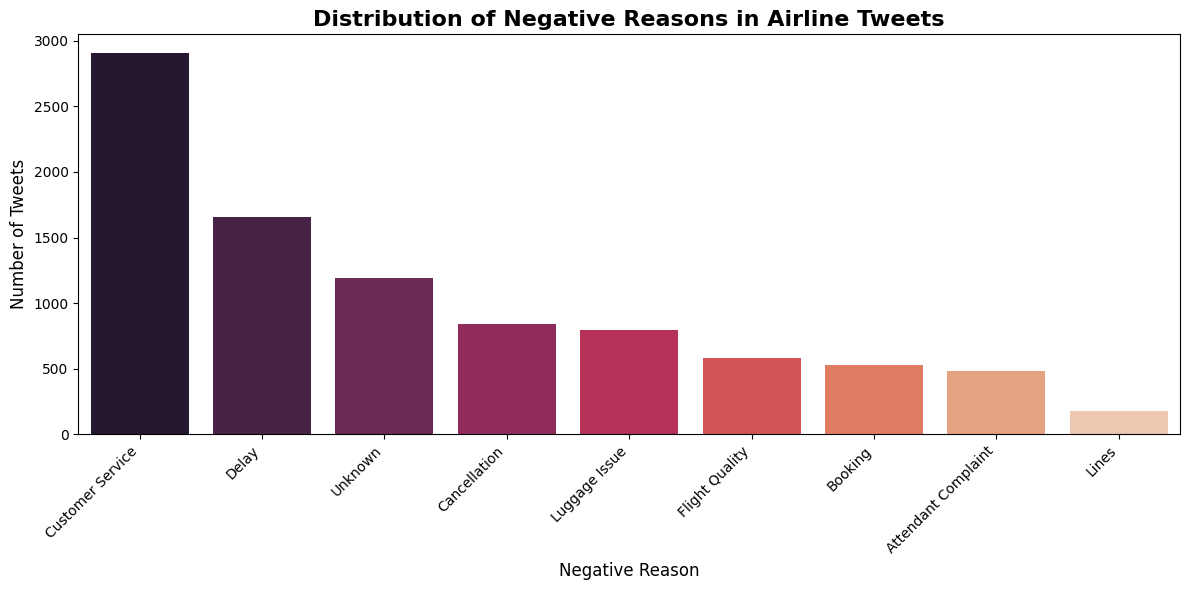

In [12]:
#Creating a dictionary mapping both luggage issues to a single category
luggage_grouping = {"Lost Luggage": "Luggage Issue","Damaged Luggage": "Luggage Issue"}

#Applying the mapping to dataframe
full_df_tweets['negativereason'] = full_df_tweets['negativereason'].replace(luggage_grouping)

#Verifying the changes
print(full_df_tweets['negativereason'].value_counts())

#Getting final negative reason counts after all mapping
final_negativereason_counts = full_df_tweets['negativereason'].value_counts()

#Plotting a barplot
plt.figure(figsize=(12, 6))
sns.barplot(x=final_negativereason_counts.index, y=final_negativereason_counts.values,hue=final_negativereason_counts.index,
            palette="rocket",legend=False)

plt.title('Distribution of Negative Reasons in Airline Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Negative Reason', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

##### Column airline

The unique values in Column airline are: 6
 
Values for airline counts:
airline
United            3822
US Airways        2913
American          2723
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64
 


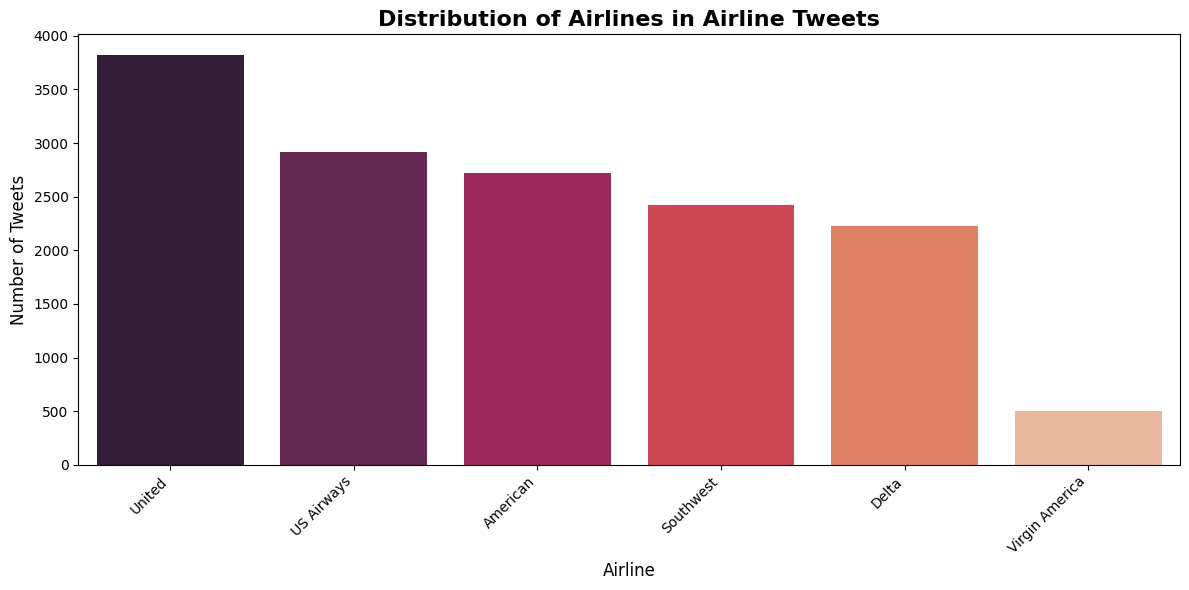

In [13]:
#Exploring Column airline

#Understanding values in Column airline
unique_airline_count = full_df_tweets['airline'].nunique()
print('The unique values in Column airline are:', unique_airline_count)
print(' ')

airline_counts = full_df_tweets['airline'].value_counts().sort_values(ascending=False)
#Sorting the counts in descending order
airline_counts = airline_counts.sort_values(ascending=False)
print('Values for airline counts:')
print(airline_counts)
print(' ')

#Plotting a barplot
plt.figure(figsize=(12, 6))
sns.barplot(x=airline_counts.index, y=airline_counts.values,hue=airline_counts.index,
            palette="rocket",legend=False)

plt.title('Distribution of Airlines in Airline Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Airline', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

##### Column retweet_count

The unique values in Column retweet_count are: 18
 
Values for retweet counts:
retweet_count
0     13838
1       639
2        66
3        22
4        17
5         5
7         3
6         3
22        2
18        1
15        1
31        1
11        1
8         1
9         1
28        1
32        1
44        1
Name: count, dtype: int64
 
count    14604.00
mean         0.08
std          0.75
min          0.00
25%          0.00
50%          0.00
75%          0.00
max         44.00
Name: retweet_count, dtype: float64


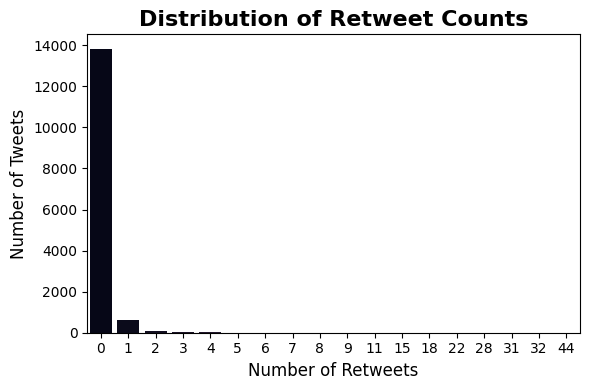

Original Skewness: 33.8772


In [14]:
#Exploring Column retweet_count
#Right Skewed

#Understanding values in Column retweet_count
unique_retweet_count = full_df_tweets['retweet_count'].nunique()
print('The unique values in Column retweet_count are:', unique_retweet_count)
print(' ')

retweet_counts = full_df_tweets['retweet_count'].value_counts().sort_values(ascending=False)
#Sorting the counts in descending order
retweet_counts = retweet_counts.sort_values(ascending=False)
print('Values for retweet counts:')
print(retweet_counts)
print(' ')

#Checking Statistics for Column retweet_count
print(full_df_tweets['retweet_count'].describe().round(2))

#Plotting barplot for the Distribution of Retweet Counts
plt.figure(figsize=(6,4))
sns.barplot(x=retweet_counts.index, y=retweet_counts.values, hue=retweet_counts.index, palette="rocket", legend=False)

plt.title('Distribution of Retweet Counts', fontsize=16, fontweight='bold')
plt.xlabel('Number of Retweets', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

#Keeping the numbers straight since they are short
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

original_skew = full_df_tweets['retweet_count'].skew()
print(f"Original Skewness: {original_skew:.4f}")

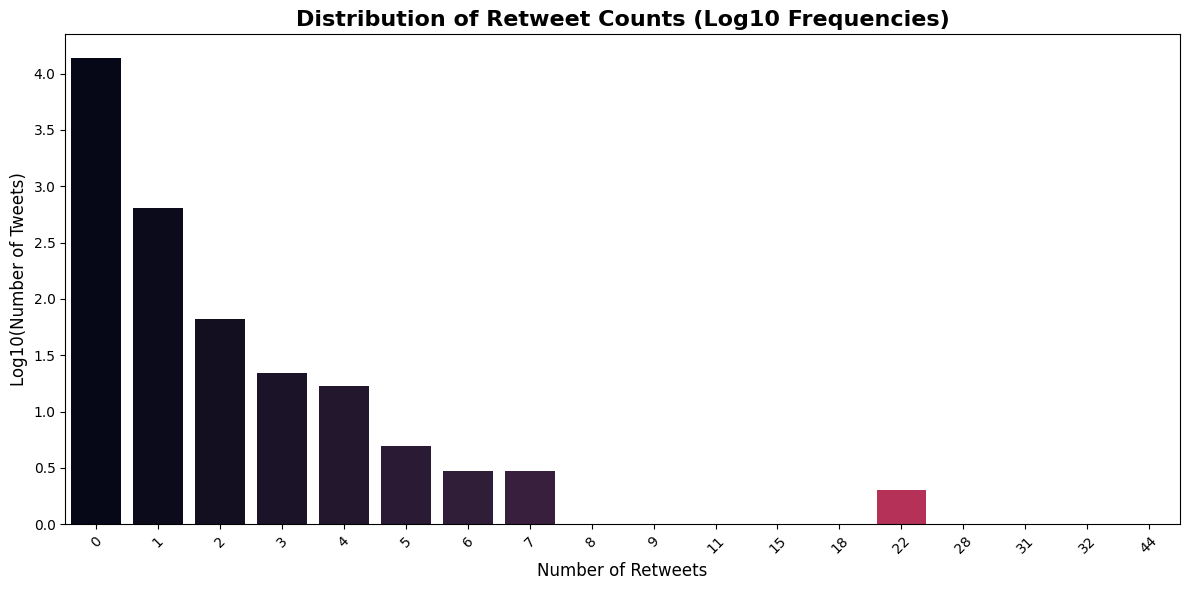

Skewness after Log10 Transformation: 6.3864
 


In [15]:
#Implementing log transformation with np.log10 (due to 0s existing in our values) to the frequencies (y-axis values)
log10_frequencies = np.log10(retweet_counts.values)

plt.figure(figsize=(12, 6))

#Plotting barplot for the Distribution of Retweet Counts after log transformation
sns.barplot(x=retweet_counts.index, y=log10_frequencies, hue=retweet_counts.index, palette="rocket", legend=False);

plt.title('Distribution of Retweet Counts (Log10 Frequencies)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Retweets', fontsize=12)
plt.ylabel('Log10(Number of Tweets)', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

full_df_tweets['retweet_count_log10'] = np.log10(full_df_tweets['retweet_count'] + 1)
transformed_skew = full_df_tweets['retweet_count_log10'].skew()
print(f"Skewness after Log10 Transformation: {transformed_skew:.4f}")
print(" ")

In [16]:
#Checking updated Statistics for Column retweet_count_log10
print(full_df_tweets['retweet_count_log10'].describe().round(2))
print(' ')

#Checking for Extreme Outliers of column retweet_count_log10

#Creating a list for all values of column retweet_count_log10
extr_retweet_count_log10 = full_df_tweets['retweet_count_log10'].to_list()

#Splitting OverallQual values in percentiles 
Q1 = np.percentile(extr_retweet_count_log10,25,method='midpoint')
Q2 = np.percentile(extr_retweet_count_log10,50,method='midpoint')
Q3 = np.percentile(extr_retweet_count_log10,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

print('retweet_count_log10 Extreme Outliers are:')
print('Minimum:', Q1 - 3 * IQR)  #lower outlier fence
print('Maximum:', Q3 + 3 * IQR)  #maximum outlier fence
print(' ')
#Most values are 0 so IQR method is not working. Will procced with zscores

#Checking top10 z_scores for extreme outliers 
top_10_z_scores=pd.Series(stats.zscore(full_df_tweets['retweet_count_log10'])).sort_values().tail(10).round(2)
print(top_10_z_scores)
print(' ')

#Checking more thorougly from value counts for outliers 5<=retweet_count<=45
outliers_to_remove = full_df_tweets.query('6 <= retweet_count <= 45').index

print(f"Number of rows identified for removal: {len(outliers_to_remove)}")
print(f"Row Indexes being dropped: {list(outliers_to_remove)}")

#Dropping outliers found 
full_df_tweets = full_df_tweets.drop(index=outliers_to_remove)

#Reseting index of DataFrame
full_df_tweets.reset_index(drop=True, inplace=True)

#Re-calculating the log column since the data changed
full_df_tweets['retweet_count_log10'] = np.log10(full_df_tweets['retweet_count'] + 1)

#Verifying the results
print('Updated Shape:', full_df_tweets.shape)
print('Top Retweet Counts remaining:')
print(full_df_tweets['retweet_count'].value_counts().sort_index(ascending=False))

count    14604.00
mean         0.02
std          0.09
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          1.65
Name: retweet_count_log10, dtype: float64
 
retweet_count_log10 Extreme Outliers are:
Minimum: 0.0
Maximum: 0.0
 
9453     11.25
7453     12.16
7111     13.59
7027     14.45
7115     15.40
5607     15.40
9999     16.56
7132     17.05
11582    17.20
11596    18.74
dtype: float64
 
Number of rows identified for removal: 17
Row Indexes being dropped: [4144, 5270, 5607, 6969, 7027, 7032, 7111, 7115, 7132, 7134, 7453, 8438, 8444, 9453, 9999, 11582, 11596]
Updated Shape: (14587, 8)
Top Retweet Counts remaining:
retweet_count
5        5
4       17
3       22
2       66
1      639
0    13838
Name: count, dtype: int64


count    14587.00
mean         0.02
std          0.08
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          0.78
Name: retweet_count_log10, dtype: float64
 


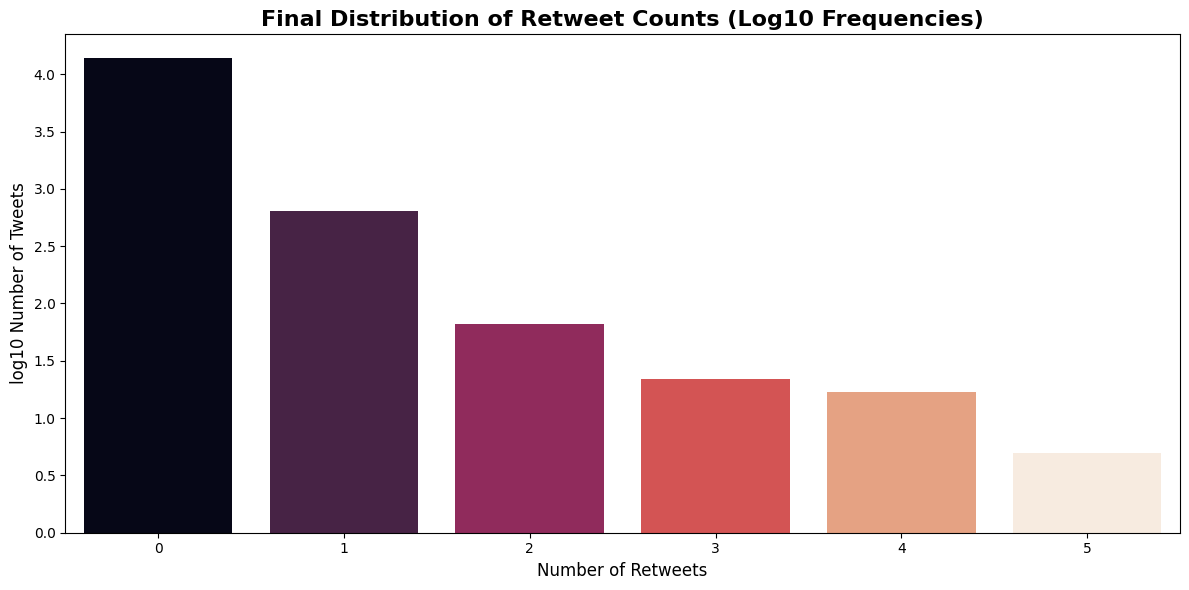

Final Skewness after Outlier Removal: 4.8285


In [17]:
#Checking updated Statistics for Column retweet_count_log10
print(full_df_tweets['retweet_count_log10'].describe().round(2))
print(' ')

#Re-calculating retweet counts for the updated dataframe
retweet_counts_updated = full_df_tweets['retweet_count'].value_counts().sort_index()

#Re-calculating the log10 frequencies for the Y-axis
log10_frequencies_updated = np.log10(retweet_counts_updated.values)

#Plotting the updated barplot
plt.figure(figsize=(12, 6))

sns.barplot(
    x=retweet_counts_updated.index, 
    y=log10_frequencies_updated, 
    hue=retweet_counts_updated.index, 
    palette="rocket", 
    legend=False
)

plt.title('Final Distribution of Retweet Counts (Log10 Frequencies)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Retweets', fontsize=12)
plt.ylabel('log10 Number of Tweets', fontsize=12)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#Final Skewness Check for column retweet_count_log10
final_skew = full_df_tweets['retweet_count_log10'].skew()
print(f"Final Skewness after Outlier Removal: {final_skew:.4f}")

##### Column tweet_created

The unique values in Column tweet_created are: 14230
 


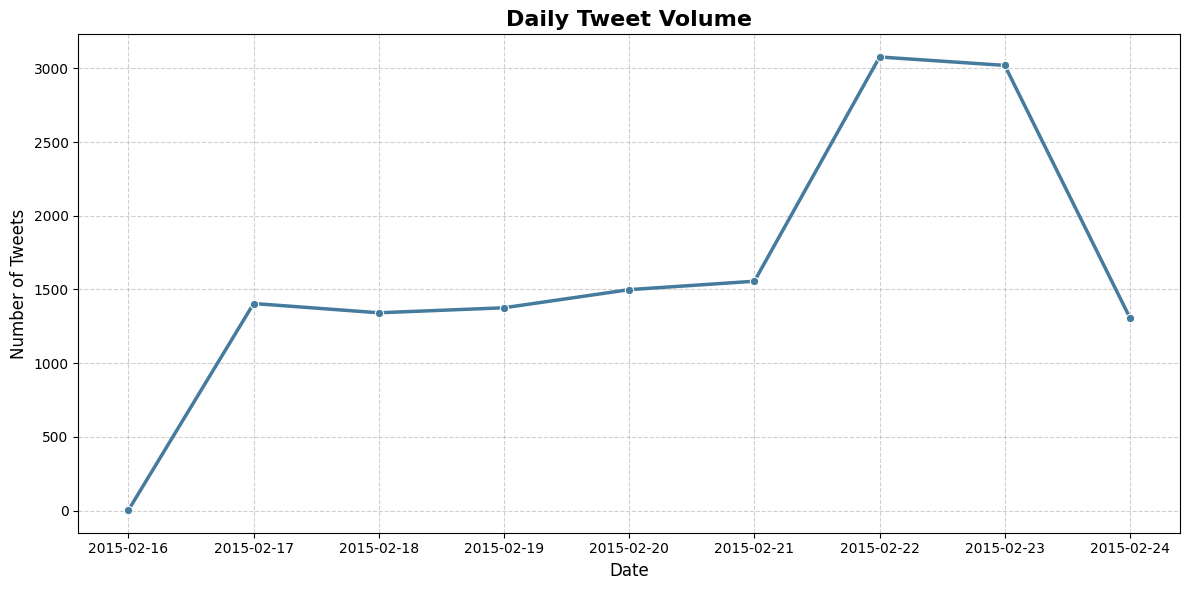

In [18]:
#Exploring Column tweet_created

#Understanding values in Column retweet_count
unique_tweet_created = full_df_tweets['tweet_created'].nunique()
print('The unique values in Column tweet_created are:', unique_tweet_created)
print(' ')

#Converting the column tweet_created to actual datetime objects
full_df_tweets['tweet_created'] = pd.to_datetime(full_df_tweets['tweet_created'])

#Extracting just the Date (YYYY-MM-DD) to group the tweets per day
full_df_tweets['tweet_date'] = full_df_tweets['tweet_created'].dt.date

#Counting tweets per day
daily_counts = full_df_tweets['tweet_date'].value_counts().sort_index()

#Plotting as a Line Chart to show tweets trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_counts.index, y=daily_counts.values, marker='o', color='#457B9D', linewidth=2.5)

plt.title('Daily Tweet Volume', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##### Main column text / raw corpus

In [19]:
#Exploring Column text

#Understanding values in Column text
unique_text_count = full_df_tweets['text'].nunique()
print('The unique values in Feature Column text are:',unique_text_count)
print(' ')

df_text_tweets = full_df_tweets[["text"]].copy()
df_text_tweets["text"] = df_text_tweets["text"].astype(str)

#Creating the corpus 
corpus=df_text_tweets["text"]

The unique values in Feature Column text are: 14410
 


###### Visualizing character tweet Count (raw corpus)

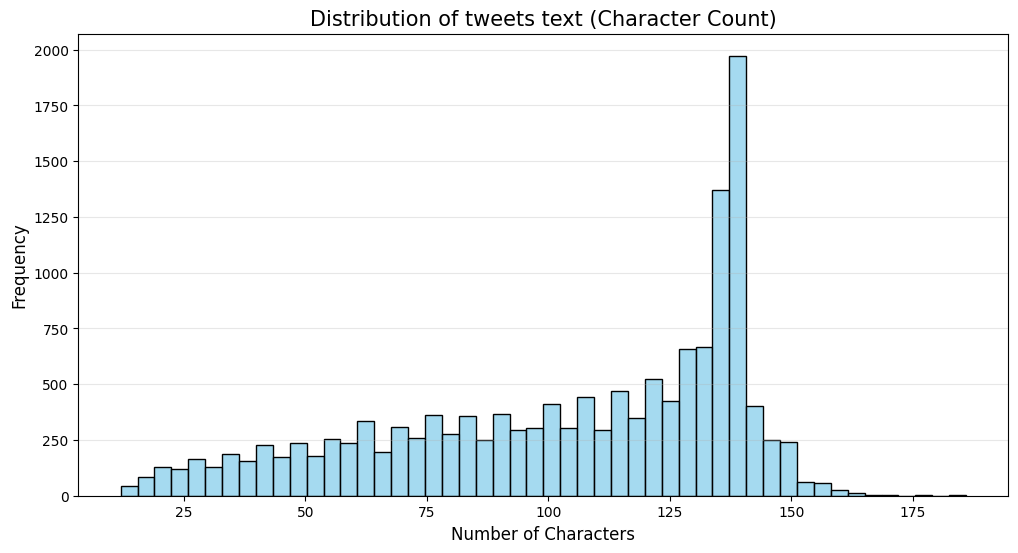

In [20]:
#Checking the number of characters present in each sentence to have a rough idea about the text headline length
#Calculating sentence lengths
df_text_tweets["char_count"] = df_text_tweets["text"].str.len()

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_text_tweets["char_count"], bins=50, color="skyblue")
plt.title("Distribution of tweets text (Character Count)", fontsize=15)
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

###### Visualizing Word tweet Count (raw corpus)

Mean Word Count: 18.00
Median Word Count: 19.00


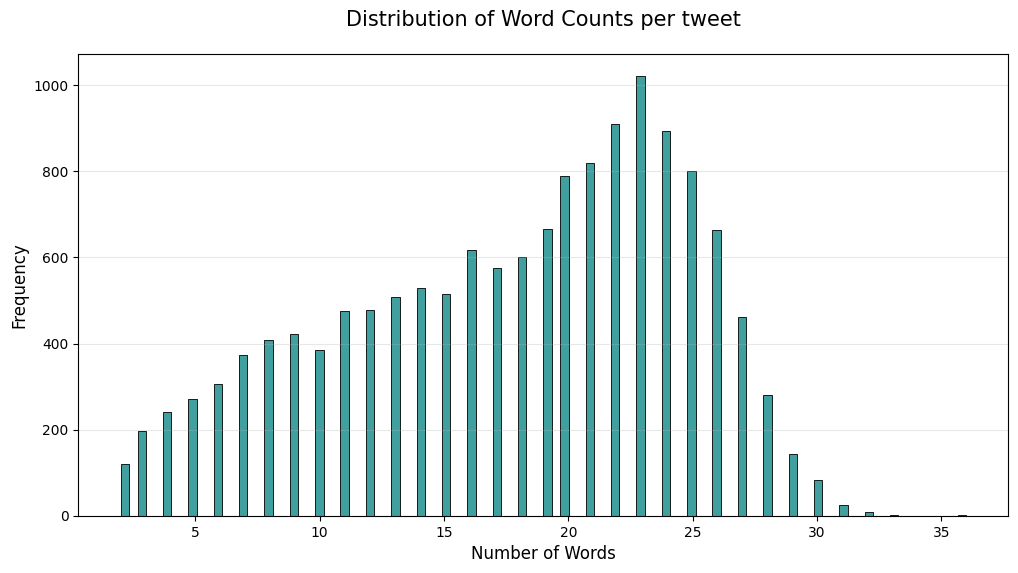

In [21]:
#Calculating word counts by splitting strings into lists
df_text_tweets["word_count"] = df_text_tweets["text"].str.split().str.len()

#Calculating key statistics
mean_words = df_text_tweets["word_count"].mean().round()
median_words = df_text_tweets["word_count"].median().round()

print(f"Mean Word Count: {mean_words:.2f}")
print(f"Median Word Count: {median_words:.2f}")

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_text_tweets["word_count"], bins=100, color="teal", label="Word Count")

plt.title("Distribution of Word Counts per tweet", fontsize=15, pad=20)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

###### Visualizing average tweet word length (raw corpus)

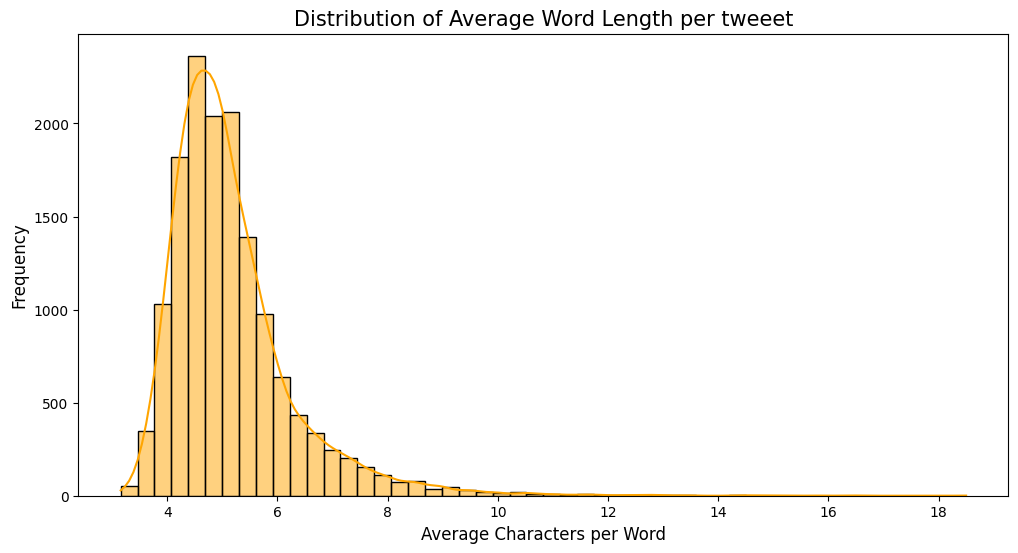

In [22]:
def get_avg_word_len(text):
    """Function to calculate average word length"""
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

df_text_tweets['avg_word_len'] = df_text_tweets['text'].apply(get_avg_word_len)

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_text_tweets['avg_word_len'], bins=50, kde=True, color="orange")

plt.title("Distribution of Average Word Length per tweeet", fontsize=15)
plt.xlabel("Average Characters per Word", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

###### Ngram exploration (Raw) for column text

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=None).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

#Initializing the raw corpus
corpus = df_text_tweets["text"]

#Extracting the top 10 for different n-gram ranges
top_unigrams = get_top_ngram(corpus, n=1)
top_bigrams = get_top_ngram(corpus, n=2)
top_trigrams = get_top_ngram(corpus, n=3)

print("Top 10 Unigrams (Raw):", top_unigrams)
print("Top 10 Bigrams (Raw):", top_bigrams)
print("Top 10 Trigrams (Raw):", top_trigrams)

Top 10 Unigrams (Raw): [('to', np.int64(8635)), ('the', np.int64(6048)), ('you', np.int64(4384)), ('united', np.int64(4163)), ('for', np.int64(3987)), ('flight', np.int64(3928)), ('on', np.int64(3790)), ('and', np.int64(3723)), ('my', np.int64(3273)), ('usairways', np.int64(3049))]
Top 10 Bigrams (Raw): [('http co', np.int64(1142)), ('thank you', np.int64(566)), ('customer service', np.int64(560)), ('on the', np.int64(545)), ('on hold', np.int64(514)), ('cancelled flightled', np.int64(504)), ('to get', np.int64(482)), ('my flight', np.int64(479)), ('for the', np.int64(455)), ('thanks for', np.int64(393))]
Top 10 Trigrams (Raw): [('on hold for', np.int64(237)), ('been on hold', np.int64(166)), ('thank you for', np.int64(145)), ('thanks for the', np.int64(144)), ('fleet on fleek', np.int64(139)), ('jetblue our fleet', np.int64(138)), ('our fleet on', np.int64(138)), ('on fleek http', np.int64(136)), ('fleek http co', np.int64(136)), ('was cancelled flightled', np.int64(105))]


###### Visualizing Top 10 Unigrams (Raw) for column text

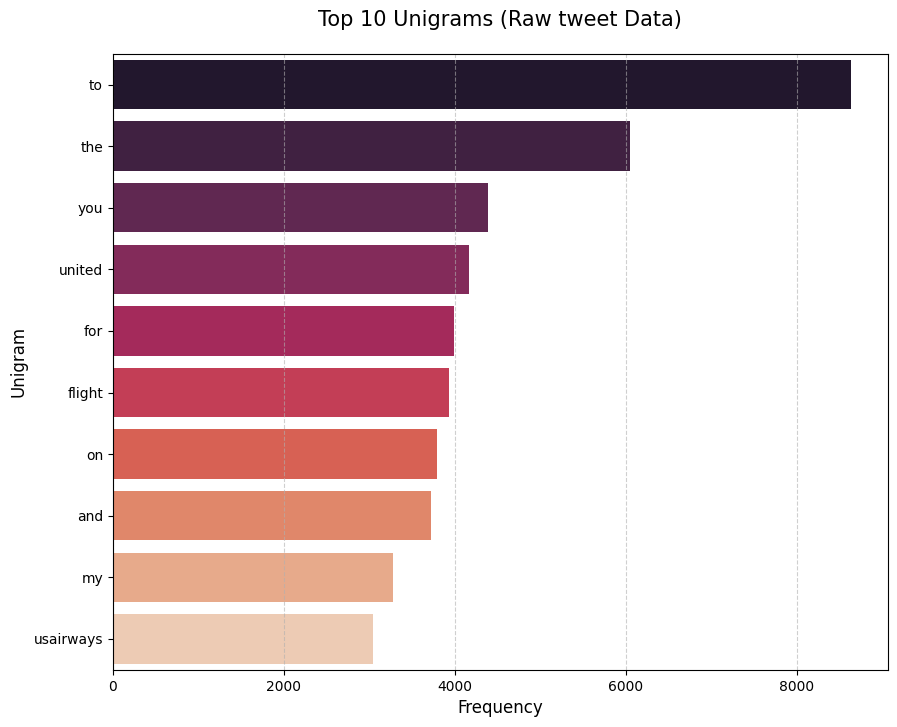

In [24]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_unigrams)

#Visualizing Top 10 Bigrams for the raw corpus
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Unigrams (Raw tweet Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Unigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

###### Visualizing Top 10 Bigrams (Raw) for column text

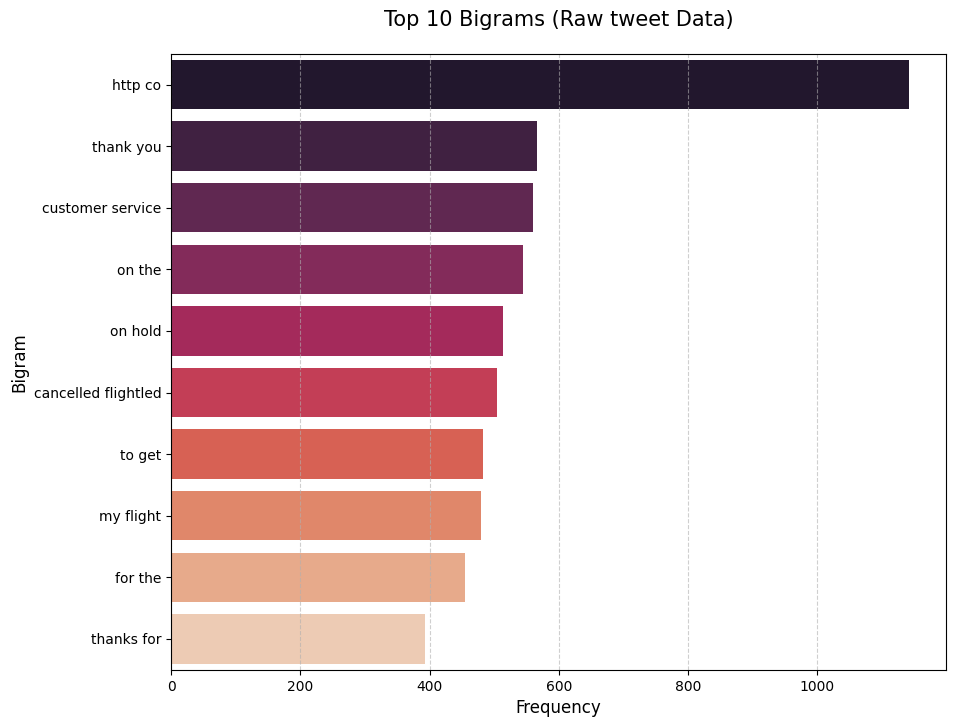

In [25]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_bigrams)

#Visualizing Top 10 Bigrams for the raw corpus
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Bigrams (Raw tweet Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Bigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

###### Visualizing Top 10 Trigrams (Raw) for column text

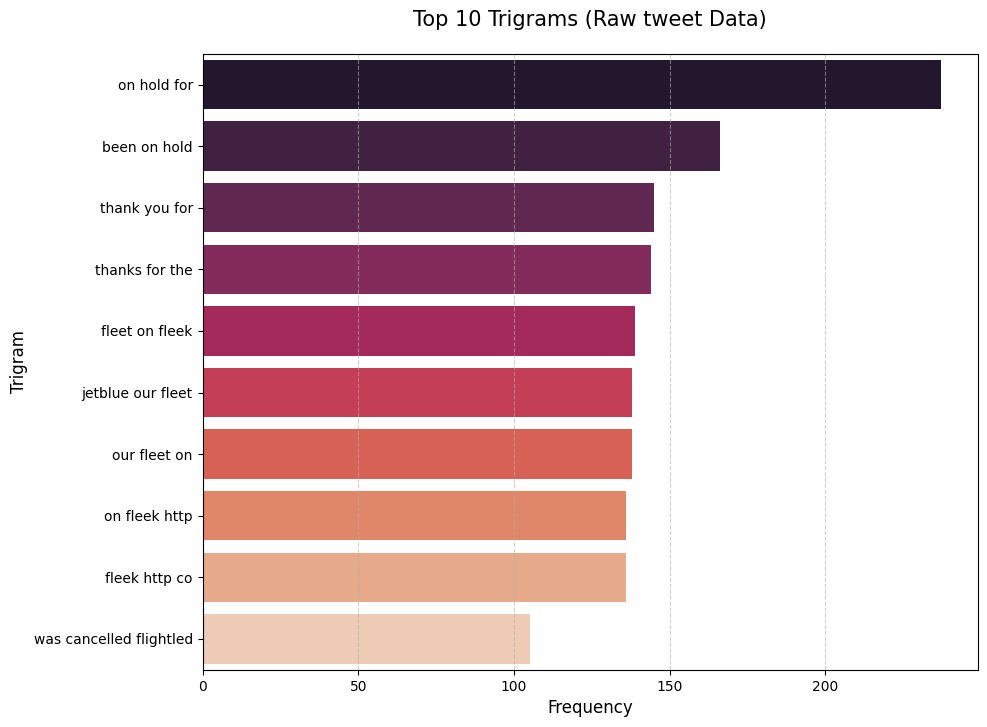

In [26]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_trigrams)

#Visualizing Top 10 Bigrams for the raw corpus
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Trigrams (Raw tweet Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Trigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

###### Topic modeling exploration (Raw) for column text

In [27]:
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model
from pyLDAvis import prepare

#Vectorizing the raw corpus
raw_corpus = df_text_tweets["text"]
tf_vectorizer = CountVectorizer(stop_words=None)
tf = tf_vectorizer.fit_transform(raw_corpus)

#Initializing and fitting LDA for n_components=6
lda_model = LatentDirichletAllocation(n_components=6, random_state=42)
lda_model.fit(tf)

#Preparing the visualization
panel = pyLDAvis.lda_model.prepare(lda_model, tf, tf_vectorizer, mds='tsne')

#Displaying the dashboard
pyLDAvis.display(panel)

##### Cleaning column text

###### Removal of HTML Tags like <'p> or <br'> of column text

In [28]:
from bs4 import BeautifulSoup

def remove_html_tags(text):
    """
    Removes HTML tags using BeautifulSoup. 
    If no tags are present, it returns the original text intact.
    """
    #checking to handle NaN/None or non-string values
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    #Parsing the text and extracting only the string content
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text(separator=" ", strip=True)

df_text_tweets["text_no_html"] = df_text_tweets["text"].apply(remove_html_tags)

#Updating corpus
corpus=df_text_tweets["text_no_html"]

###### Removal of urls in the cleaned from html tags text column

In [29]:
import re

def remove_urls(text):
    """
    Removes URLs from the text using regular expressions.
    If no URLs are present, it returns the original previous text intact.
    """
    #Checking to handle NaN/None or non-string values
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    #Regex pattern to match http, https, and www URLs
    url_pattern = re.compile(r'http[s]?://\S+|www\.\S+')
    
    #Replacing the matched URLs with an empty string
    return url_pattern.sub(r'', text)

#Applying the URL removal to the text that just had HTML removed
df_text_tweets["text_no_url"] = df_text_tweets["text_no_html"].apply(remove_urls)

#Updating corpus
corpus=df_text_tweets["text_no_url"]

###### Removal of Emoticons like :-) & translating them into text in till now cleaned text rows

In [30]:
import re

#Creating a dictionary of common emoticons and their text translations
EMOTICON_DICT = {
    r':-\)': ' happy ', r':\)': ' happy ', r':-\]': ' happy ', r':\]': ' happy ',
    r':-\(': ' sad ', r':\(': ' sad ', r':-\[': ' sad ', r':\[': ' sad ',
    r':-D': ' laugh ', r':D': ' laugh ', r'XD': ' laugh ',
    r';-\)': ' wink ', r';\)': ' wink ',
    r':-P': ' playful ', r':P': ' playful '
}

def translate_emoticons(text):
    """Translates ASCII emoticons to words BEFORE punctuation is removed"""
    text = str(text)
    for emoticon, word in EMOTICON_DICT.items():
        text = re.sub(re.escape(emoticon), word, text, flags=re.IGNORECASE)
    return text

#Applying this to the raw text :
df_text_tweets["after_emoticons_translation_text"] = df_text_tweets["text_no_url"].apply(translate_emoticons)

#Updating corpus
corpus=df_text_tweets["after_emoticons_translation_text"]

###### Removal of Emojis like 😀 & translating them into text in till now cleaned text rows

In [31]:
import emoji

def translate_emoji_to_words(text):
    """Translates emojis into text aliases (e.g., 👍 becomes 'thumbs up')"""
    translated_text = emoji.demojize(str(text), delimiters=(" ", " "))
    
    #Replacing underscores with spaces so 'thumbs_up' for example becomes 'thumbs up'
    translated_text = translated_text.replace("_", " ")
    
    return translated_text

#Applying it to the latest cleaned text column
df_text_tweets["after_emojis_emoticons_translation_text"] = df_text_tweets["after_emoticons_translation_text"].apply(translate_emoji_to_words)

#Cleaning up any extra whitespace left behind
df_text_tweets["after_emojis_emoticons_translation_text"] = df_text_tweets["after_emojis_emoticons_translation_text"].str.replace(r'\s+', ' ', regex=True).str.strip()

#Updating corpus
corpus=df_text_tweets["after_emojis_emoticons_translation_text"]

#display(df_text_tweets.head())
#print(' ')
#display(df_text_tweets.sample())
#print(' ')
#display(df_text_tweets.tail())

###### Removal of # in till now cleaned text rows

In [32]:
#Removing # symbol
df_text_tweets["after_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_emojis_emoticons_translation_text"]
    .str.replace('#', '', regex=False)       #Removing # symbol 
    .str.replace(r'\s+', ' ', regex=True)    #Cleaning extra whitespace
    .str.strip()                             #Removing leading/trailing spaces
)

#In case wanted to remove all #hashtag
#df_text_tweets["after_#_emojis_emoticons_translation_text"] = (
#    df_text_tweets["after_emojis_emoticons_translation_text"]
#    .str.replace(r'#\w+', '', regex=True)    #Removing #word completely
#    .str.replace(r'\s+', ' ', regex=True)    #Cleaning extra whitespace
#    .str.strip()                             #Removing leading/trailing spaces
#)

#Updating corpus
corpus=df_text_tweets["after_#_emojis_emoticons_translation_text"]

#Checking updated corpus
df_text_tweets["after_#_emojis_emoticons_translation_text"].sample(15)

309                                                                                                    @VirginAmerica is saving my sanity right now:
14017                                                                   @AmericanAir I ended up on a flight to LA my fourth time on standby. Thanks!
0                                                                                                                @VirginAmerica What @dhepburn said.
586             @united OKC ticket agent Roger McLarren(sp?) LESS than helpful with our Intl group travel problems Can't find a supervisor for help.
7279                                    @JetBlue pilot: "Don't worry folks there's a backup for the backup for every part of this plane." Thanks guy
5184     @SouthwestAir I had to switch airlines and eat the difference (which was not insubstantial) and Cancelled Flight all plans for sat & sun :(
8560                                            @JetBlue I'm trying to add my 2012 flights to my Badges ac

###### Removal of @ in till now cleaned text rows

In [33]:
#Removing @ symbol 
df_text_tweets["after_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_#_emojis_emoticons_translation_text"]  
    .str.replace('@', '', regex=False)          # Removing @ symbol
    .str.replace(r'\s+', ' ', regex=True)       # Cleaning extra whitespace
    .str.strip()                                # Removing leading/trailing spaces
)

#Removing @username completely in case wanted
#df_text_tweets["after_@_#_emojis_emoticons_translation_text"] = (
#    df_text_tweets["after_#_emojis_emoticons_translation_text"]
#    .str.replace(r'@\w+', '', regex=True)       # Removing @username completely
#    .str.replace(r'\s+', ' ', regex=True)       # Cleaning extra whitespace
#    .str.strip()                                # Removing leading/trailing spaces
#)

#Updating corpus
corpus=df_text_tweets["after_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
df_text_tweets["after_@_#_emojis_emoticons_translation_text"].sample(15)

12285                                                                                                   AmericanAir and is there a delay on our connection to pns?
10085                                                                                                        USAirways with chocoLate Flight please... i m melting
7251                                                  jetblue - WTF, stuck at JFK for 2+ hrs in a delay to Boston cuz u say snow. No snow on weather map!!! WTF!!!
3786     united how can i trust United with future Flight Booking Problemss when a confirmed, ticketed and purchased ticket is Cancelled Flightled after the fact?
2283                                                                                                united Yes, they did. Must have fixed the broken ramp. Thanks!
2229                                                           united could really use your help getting our bags at IAD. We're headed to YOW but now going to YXU
11373                 

###### Implementing lower case in till now cleaned text rows

In [34]:
df_text_tweets["after_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_@_#_emojis_emoticons_translation_text"]
    .str.lower()                                #Converting to lowercase
    .str.replace(r'\s+', ' ', regex=True)       #Cleaning extra whitespace
    .str.strip()                                #Removing leading/trailing spaces
)

#Updating corpus
corpus=df_text_tweets["after_lower_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
df_text_tweets["after_lower_@_#_emojis_emoticons_translation_text"].sample(15)

4924                                                             southwestair still planing on flights into dal? we are trying to fly in tomorrow from lax
12614                                                     .americanair hopefully it's all fixed. they've got a new aircraft for us- just waiting to board.
1197     united you are the worst airline in the world! from your crap website to your worthless app to your late flight flight. you suck! just shut down.
3683            united honestly, i stopped trying to report things via website. now i just laugh. flights work. miles accrue. i'm sure it's just cosmetic.
6237                   southwestair allows you to change a flight once for no fee, yay! i will always book flights with them. americanair changes you $200
13999             americanair i need to get from albuquerque, nm, usa, to cebu, philippines. i'm providing educational help for 800 kids. can you help me?
4109                united now submitted for the third time, please ch

###### Removing punctuation , .  (no removal of ! ?) in till now cleaned text rows

In [35]:
#Removing punctuation but keeping ! and ? as these are important for sentiment analysis
df_text_tweets["after_punct_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_lower_@_#_emojis_emoticons_translation_text"]
    .str.replace(r'[^\w\s!?]', '', regex=True)   #Removing punctuation but keeping ! and ?
    .str.replace(r'\s+', ' ', regex=True)        #Cleaning extra whitespace
    .str.strip()                                 #Removing leading/trailing spaces
) 

#Updating corpus
corpus=df_text_tweets["after_punct_lower_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
df_text_tweets["after_punct_lower_@_#_emojis_emoticons_translation_text"].sample(15)

13699                    americanair first flight is cancelled flightled been on hold for 4 hours need information and getting none help?
4831                                                                                      southwestair free tv watching daytona 500! boss
10637                                usairways you need to check information regarding hotels shuttles re routing flights delayed flights
2753                                                            united i just had an interview how long does it take before you hear back
299                                                                               virginamerica weather delays next few weeks jfk bos dca
7860                                                                          jetblue when are you guys doing a dualcam with redreserve ?
1198                                                                                 united scotthroth scott need a good book suggestion?
2882     united i booked and paid 

###### Removing digits in till now cleaned text rows

In [36]:
#Removing digits
df_text_tweets["after_digits_punct_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_punct_lower_@_#_emojis_emoticons_translation_text"]
    .str.replace(r'\d+', '', regex=True)         #Removing digits
    .str.replace(r'\s+', ' ', regex=True)        #Cleaning extra whitespace
    .str.strip()                                 #Removing leading/trailing spaces
)

#Updating corpus
corpus=df_text_tweets["after_digits_punct_lower_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
df_text_tweets["after_digits_punct_lower_@_#_emojis_emoticons_translation_text"].sample(15)

955                                      united i filed a delayed bag report on saturday! my flight was cancelled flightled and i never went anywhere!
5866                                                       southwestair im excited too but perhaps you could scale your excitement back by a few weeks
3984                united my golf bag didnt have a top cover staffers said they couldnt check without a type of cover or wrap forced to leave the bag
9688     usairways is stranding your customers not reflight booking problems them and then not answering the phone the way you treat platinum members?
206          virginamerica thanks for a great flight from la to boston! pilots did a great job landing in the snow can we go back to la now? seriously
1021                  united big thanks to ms winston for assisting me over the phone with a baggage claim issue today she really went the extra mile!
7480                                                                                     jetbl

###### Removing stopwords (not the negation words) in till now cleaned text rows

In [37]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

#Defining stopwords and keeping negation words
stop_words = set(stopwords.words('english'))

negation_words = {"no", "not", "nor", "never", "neither", "nobody", "nothing",
                  "nowhere", "don't", "doesn't", "didn't", "won't", "wouldn't",
                  "couldn't", "shouldn't", "isn't", "aren't", "wasn't", "weren't",
                  "hasn't", "haven't", "hadn't", "can't", "cannot"}

#Removing negation words from stopwords list
stop_words = stop_words - negation_words

#Removing stopwords
df_text_tweets["after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_digits_punct_lower_@_#_emojis_emoticons_translation_text"]
    .apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
    .str.replace(r'\s+', ' ', regex=True)        # Cleaning extra whitespace
    .str.strip()                                 # Removing leading/trailing spaces
)

#Updating corpus
corpus=df_text_tweets["after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
display(df_text_tweets["after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].sample(15))
#print(' ')
#display(df_text_tweets["after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].head(15))
#print(' ')
#display(df_text_tweets["after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].tail(15))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\roxan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


3401               united abused threatened forced travel lower cabine last seat yesterdays flight houston sao paulo
8830                                          jetblue airways sees significant drop short interest jblu mideast time
9122                                                                                          usairways nope not yet
8086                                   jetblue thanks gent phone fixed bosmco flight fee waiver! flyfi ! forget name
6858                                                                                         rt jetblue fleets fleek
531                                                     united need use chase united club pass yr old son come pass?
135         virginamerica need register service dog first class ticket sfo dulles phone queue hour longer pls advise
11468            usairways announced people going fl via charlotte would go different plane gate direct flight logic
8416                       jetblue wasnt service credit voucher 

###### Removal of Chat Words & translating them into text in till now cleaned text rows

In [38]:
import re

SENTIMENT_CHAT_WORDS_DICT = {
    #neutral expansions — no sentiment signal, but aid tokenization
    "a3":       "anytime anywhere anyplace",
    "afaik":    "as far as i know",
    "afk":      "away from keyboard",
    "aka":      "also known as",
    "approx":   "approximately",
    "asap":     "as soon as possible",
    "atk":      "at the keyboard",
    "atm":      "at the moment",
    "b4n":      "bye for now",
    "bak":      "back at keyboard",
    "bbl":      "be back later",
    "bbs":      "be back soon",
    "bfn":      "bye for now",
    "brb":      "be right back",
    "brt":      "be right there",
    "btw":      "by the way",
    "b/c":      "because",
    "cu":       "see you",
    "cul8r":    "see you later",
    "cya":      "see you",
    "dm":       "direct message",
    "eod":      "end of day",
    "eow":      "end of week",
    "eta":      "estimated time of arrival",
    "faq":      "frequently asked questions",
    "fwiw":     "for what its worth",
    "fyp":      "for you page",
    "fyi":      "for your information",
    "gal":      "get a life",
    "gmta":     "great minds think alike",
    "hbu":      "how about you",
    "ic":       "i see",
    "icq":      "i seek you",
    "iirc":     "if i recall correctly",
    "iow":      "in other words",
    "irl":      "in real life",
    "iykyk":    "if you know you know",
    "l8r":      "later",
    "ldr":      "long distance relationship",
    "lmk":      "let me know",
    "ltns":     "long time no see",
    "m8":       "mate",
    "mfw":      "my face when",
    "mrw":      "my reaction when",
    "mte":      "my thoughts exactly",
    "nrn":      "no reply necessary",
    "oic":      "oh i see",
    "ootl":     "out of the loop",
    "pov":      "point of view",
    "prt":      "party",
    "pls":      "please",
    "plz":      "please",
    "prw":      "parents are watching",
    "rn":       "right now",
    "tba":      "to be announced",
    "tbd":      "to be determined",
    "tbf":      "to be fair",
    "tfw":      "that feeling when",
    "thx":      "thank you",
    "ttfn":     "ta ta for now",
    "ttyl":     "talk to you later",
    "u2":       "you too",
    "u4e":      "yours for ever",
    "w/":       "with",
    "w/o":      "without",
    "wb":       "welcome back",
    "wbu":      "what about you",
    "wuf":      "where are you from",
    "wtg":      "way to go",
    "wyd":      "what you doing",
    "wywh":     "wish you were here",
    "ik":       "i know",
    "sk8":      "skate",
    "bae":      "before anyone else",
    "nvm":      "never mind",
    "tbh":      "to be honest",
    "tldr":     "too long did not read",
    "tntl":     "trying not to laugh",
    "adih":     "another day in hell",
    "ngl":      "not going to lie",
    "no cap":   "seriously no lie",
    "periodt":  "and that is final",
    "ikr":      "i agree completely",
    "vibe":     "atmosphere",
    "tea":      "gossip",
    "clout":    "social influence",
    "receipts": "evidence",
    "flexing":  "showing off",
    "simp":     "overly devoted person",
    "stan":     "devoted fan",
    "it's giving": "it resembles",
    "no tea no shade": "not trying to offend",

    # -------------------------------------------------------------------------
    #laughter — graded by intensity (positive sentiment)
    "lol":      "amused",                       
    "haha":     "amused",
    "hehe":     "amused",
    "lmao":     "laughing hysterically",        
    "lmfao":    "laughing hysterically",        
    "rofl":     "laughing hysterically",
    "roflol":   "laughing hysterically",
    "rotflmao": "laughing hysterically",
    "bwl":      "laughing hysterically",
    "csl":      "laughing",                     

    # -------------------------------------------------------------------------
    #sentiment polarity flippers — highest risk if missed
    "jk":       "just kidding",                 #negates preceding sentiment
    "/s":       "sarcastic",                    #sarcasm marker
    "nah":      "no disagree",                  #dismissal
    "/j":       "joking",
    "/lh":      "lighthearted",
    "/srs":     "serious",
    "/pos":     "positive intent",
    "/neg":     "negative intent",

    # -------------------------------------------------------------------------
    #intensifiers — amplifying surrounding sentiment
    "af":       "extremely",                    #"tired af", "happy af"
    "asf":      "extremely",
    "deadass":  "seriously",
    "fr fr":    "very seriously",               #must be matched before "fr"
    "fr":       "for real",
    "lowkey":   "somewhat",
    "highkey":  "very much",
    "no cap":   "seriously",

    # -------------------------------------------------------------------------
    #strong negqtive sentiment
    "wtf":          "outraged",
    "fml":          "my life is terrible",
    "idgaf":        "i do not care at all",
    "smh":          "shaking my head in disappointment",
    "smfh":         "extremely disappointed",
    "ffs":          "for crying out loud",
    "istg":         "i swear to god",
    "pita":         "annoying",
    "oof":          "that is unfortunate",
    "yikes":        "that is alarming",
    "pressed":      "upset and bothered",
    "triggered":    "offended",
    "salty":        "bitter and upset",
    "shade":        "subtle disrespect",
    "trash":        "terrible",
    "garbage":      "terrible",
    "flop":         "failure",
    "cope":         "denial of reality",
    "seethe":       "be angry about it",
    "problematic":  "offensive behavior",
    "toxic":        "harmful behavior",
    "clout chasing":"seeking attention insincerely",
    "cancel":       "publicly boycott",
    "dragged":      "publicly criticized",
    "ratio":        "post was widely rejected",
    "cooked":       "in serious trouble",
    "mid":          "mediocre",
    "sus":          "suspicious",
    "cringe":       "embarrassing",
    "cap":          "lie",
    "npc":          "boring unoriginal person",
    "unhinged":     "erratic behavior",
    "villain era":  "embracing selfish behavior",
    "touch grass":  "disconnected from reality",
    "rent free":    "obsessively thinking about",
    "chronically online": "too absorbed in internet culture",
    "caught in 4k": "caught red-handed",
    "community noted": "publicly fact checked and wrong",
    "l take":       "bad opinion",
    "ghosted":      "ignored and rejected",
    "shook":        "shocked and disturbed",
    "not okay":     "distressed",

    # -------------------------------------------------------------------------
    #strong positive sentiment
    "gr8":      "great",
    "g9":       "genius",
    "gn":       "good night",
    "goat":     "greatest of all time",
    "goated":   "greatest of all time",
    "gg":       "well played",
    "fc":       "fingers crossed",
    "bsaaw":    "big smile and a wink",
    "blessed":  "grateful and happy",
    "thriving":  "doing very well",
    "fire":     "excellent",
    "lit":      "exciting and excellent",
    "elite":    "top quality",
    "valid":    "acceptable and good",
    "drip":     "stylish appearance",
    "vibing":   "feeling relaxed and happy",
    "slaps":    "is excellent",
    "hits":     "is very good",
    "iconic":   "remarkably impressive",
    "slay":     "performed impressively",
    "bussin":   "delicious and amazing",
    "based":    "admirable and correct",
    "rizz":     "natural charisma",
    "ate":      "did that perfectly",
    "glow up":  "impressive self improvement",
    "hits different": "feels uniquely special",
    "understood the assignment": "performed perfectly",
    "w":        "win",                          
    "fimh":     "forever in my heart",
    "hbd":      "happy birthday",

    # -------------------------------------------------------------------------
    #emotional / relational — carry sentiment through expansion
    "idc":      "i do not care",
    "idk":      "i do not know",
    "ifyp":     "i feel your pain",
    "ilu":      "i love you",
    "ily":      "i love you",
    "imu":      "i miss you",
    "imho":     "in my humble opinion",
    "imo":      "in my opinion",
    "omg":      "oh my god",
    "omfg":     "oh my god incredibly shocked",
    "fomo":     "fear of missing out",
    "woke":     "socially aware",

    # -------------------------------------------------------------------------
    # Gen Z / current slang common on Twitter 
    "delulu":       "delusionally optimistic",
    "main character":"believes they are the center of attention",
    "l":            "loss",                     
    "npc":          "boring unoriginal person",
    "sus":          "suspicious",
    "periodt":      "and that is final",
    "no cap":       "seriously no lie",
    "slay":         "performed impressively",
    "mid":          "mediocre",
    "bussin":       "delicious and amazing",
    "ratio":        "post was widely rejected",
    "based":        "admirable and correct",
    "cringe":       "embarrassing",
    "cap":          "lie",
    "simp":         "overly devoted person",
    "stan":         "devoted fan",
    "oof":          "that is unfortunate",
    "yikes":        "that is alarming",
    "rizz":         "natural charisma",
    "ate":          "did that perfectly",
    "understood the assignment": "performed perfectly",
    "rent free":    "obsessively thinking about",
    "touch grass":  "disconnected from reality",
    "villain era":  "embracing selfish behavior",
    "chronically online": "too absorbed in internet culture",
    "unhinged":     "erratic behavior",
    "caught in 4k": "caught red-handed",
    "community noted": "publicly fact checked and wrong",

}

#Remove duplicate keys and keeping last occurrence
SENTIMENT_CHAT_WORDS_DICT = dict(SENTIMENT_CHAT_WORDS_DICT)

#==================================================================================================
#Context-dependent words
#Words that can be literal or slang are not replaced blindly but with a secondary context-aware pass 
#==================================================================================================
CONTEXT_DEPENDENT_WORDS = {
    "dead":     "laughing uncontrollably",    #"i'm dead" = amused, but "dead" literally = negative
    "crying":   "laughing or very emotional",
    "screaming":"shocked or excited",
    "kill":     "very funny or impressive",   #"this is killing me" = positive amusement
    "dying":    "laughing uncontrollably",
    "shook":    "shocked and disturbed",
    "sick":     "very impressive",            #"that's sick" = positive in slang
    "wicked":   "very impressive",
    "bad":      "very impressive",            #"that's bad" = positive in some contexts
    "savage":   "impressively bold",
    "brutal":   "extremely harsh",
    "insane":   "extremely impressive",       #can be positive or negative
    "nuts":     "extremely impressive or unbelievable",
    "wild":     "extremely surprising",
}

#=============================================================================
#SAFE REPLACEMENT FUNCTION
#=============================================================================
def apply_chat_dict(text: str, chat_dict: dict = SENTIMENT_CHAT_WORDS_DICT) -> str:
    """
    Replaces chat abbreviations in text using word-boundary-safe regex.
    - Lowercases input before matching
    - Sorts keys by length descending so longer matches win (e.g. 'fr fr' before 'fr')
    - Uses word boundaries to prevent substring corruption
    """
    text = text.lower()
    sorted_keys = sorted(chat_dict.keys(), key=len, reverse=True)
    for key in sorted_keys:
        #Escaping special regex chars in key (e.g. "w/" contains "/")
        escaped_key = re.escape(key)
        pattern = r'\b' + escaped_key + r'\b'
        text = re.sub(pattern, chat_dict[key], text)
    return text

#Applying chat words translation
df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]
    .apply(lambda x: apply_chat_dict(x, SENTIMENT_CHAT_WORDS_DICT))
    .str.replace(r'\s+', ' ', regex=True)        #Cleaning extra whitespace
    .str.strip()                                 #Removing leading/trailing spaces
)

#Updating corpus
corpus=df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
display(df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].sample(15))
#print(' ')
#display(df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].head(15))
#print(' ')
#display(df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].tail(15))

11971       americanair key point confusion whether make change even though initial flight booking problems us airways metal?
2580                                                                                             united nice early back home!
8674                                                                  jetblue okayim actually gossip kinda guy anyway thanks!
10593                                                    usairways baggage drop phl bc incredibly backed unacceptable service
8708                                                                                    jetblue claimed not happy way treated
4161        united cant believe united cant find someone simply check seat back missing passport loved united debating choice
11583                              usairways jfk baggage office actually run paper hotel vouchers thislinehasntmovedforanhour
10259                                                     usairways sitting runway hours leave airport wo luggage ur s

###### Checking for remaining stopwords not properly cleaned in till now cleaned text rows

In [39]:
from nltk.corpus import stopwords

stop_words = stop_words - negation_words

#Checking remaining stopwords in corpus
def find_remaining_stopwords(text):
    words = text.split()
    return [word for word in words if word in stop_words]

remaining = df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].apply(find_remaining_stopwords)

from collections import Counter
all_remaining = [word for sublist in remaining for word in sublist]
stopword_counts = Counter(all_remaining)

print(f"Total remaining stopword instances: {sum(stopword_counts.values())}")
print(f"Unique remaining stopwords: {len(stopword_counts)}")
print("Top 20 remaining stopwords:")
print(stopword_counts.most_common(20))

Total remaining stopword instances: 418
Unique remaining stopwords: 25
Top 20 remaining stopwords:
[('as', 89), ('you', 86), ('my', 40), ('and', 36), ('by', 24), ('the', 24), ('for', 23), ('in', 22), ('your', 18), ('of', 9), ('is', 8), ('before', 6), ('very', 5), ('i', 5), ('that', 4), ('do', 4), ('now', 3), ('what', 2), ('its', 2), ('when', 2)]


###### Second pass on stopwords removal to clean reintroduced stopwords from chat word expansion in till now cleaned text rows

In [40]:
df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]
    .apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
    .str.replace(r'\s+', ' ', regex=True)        #Cleaning extra whitespace
    .str.strip()                                 #Removing leading/trailing spaces
)

#Updating corpus
corpus=df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
display(df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].sample(15))
#print(' ')
#display(df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].head(15))
#print(' ')
#display(df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].tail(15))


#Verifying no stopwords remain (should be None)
remaining = df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].apply(find_remaining_stopwords)
all_remaining = [word for sublist in remaining for word in sublist]
print(' ')
print(f"Remaining stopwords after second pass to clean reintroduced stopwords from chat word expansion: {len(all_remaining)}")

1374     united cancelled flighted flight delays lost luggage again! youre worst! disgraceful! awful company horrible service!
8767                                                                             jetblue accepting apple pay mobile enterprise
6601                              southwestair ive airline everyone else great soured whole experience hope shes not next time
13445                                                                     americanair dfw accepting arrivals departures today?
2309                 united possible make ticket change via twitter? traveling internationally cant make calls thanks advance!
8797                jetblue gary serving us fll airport counter really true blue! makes feel home even jetblue flight delayedl
8407                                        jetblue rqstd upgrade mint lax told no used points! turn bcz used points? trueblue
7205                                                               jetblue booked work added upgrade seat need 

 
Remaining stopwords after second pass to clean reintroduced stopwords from chat word expansion: 0


###### Dropping not needed any more columns in dataframe

In [41]:
df_text_tweets.drop(["char_count","word_count","avg_word_len", "text_no_html","text_no_url","after_emoticons_translation_text",
                              "after_emojis_emoticons_translation_text","after_#_emojis_emoticons_translation_text", 
                              "after_@_#_emojis_emoticons_translation_text","after_lower_@_#_emojis_emoticons_translation_text",
                               "after_punct_lower_@_#_emojis_emoticons_translation_text",
                               "after_digits_punct_lower_@_#_emojis_emoticons_translation_text",
                               "after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text",
                               "after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"
                              ],axis=1, inplace=True, errors='ignore')

#Checking at the moment columns
display(df_text_tweets.head())
#print(' ')
#display(df_text_tweets.sample(5))
#print(' ')
#display(df_text_tweets.tail())

,text,after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text
0,@VirginAmerica What @dhepburn said.,virginamerica dhepburn said
1,@VirginAmerica plus you've added commercials to the experience... tacky.,virginamerica plus youve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,virginamerica didnt today must mean need take another trip!
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",virginamerica really aggressive blast obnoxious entertainment guests faces little recourse
4,@VirginAmerica and it's a really big bad thing about it,virginamerica really big bad thing


###### Most Frequent words check in till now cleaned text rows

In [42]:
top_50_words = df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].str.split().explode().value_counts().head(50)
print(top_50_words)

after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text
united           4141
flight           3732
usairways        3044
americanair      2917
southwestair     2448
jetblue          2335
not              1535
no               1471
get              1335
cancelled        1049
thanks            877
service           873
im                762
customer          741
time              714
thank             706
us                682
help              651
hours             628
hold              616
flights           607
please            589
cant              575
plane             572
still             566
need              552
would             547
one               545
virginamerica     521
delayed           499
gate              498
dont              498
back              485
call              483
flightled         467
hour              463
got               459
face              452
bag               435
like              426
late              424
phone     

###### Inserting custom words in the stopwords & removing them from till now cleaned text rows

In [43]:
from nltk.corpus import stopwords

#Defining negation words to keep
negation_words = {"no", "not", "nor", "never", "neither", "nobody", "nothing",
                  "nowhere", "don't", "doesn't", "didn't", "won't", "wouldn't",
                  "couldn't", "shouldn't", "isn't", "aren't", "wasn't", "weren't",
                  "hasn't", "haven't", "hadn't", "can't", "cannot"}

#Defining custom filler words
custom_words_to_ignore = {"im", "us", "flightled", "got", "one", "way", "guys", "like", "face","ive","fleek","fleets","rt","folded","hands",
                         "get", "go", "make", "say", "take","would", "still", "back","thats", "youre","try","give","flightr","reflight",
                         "flighted","tear","joy","smile","eye"}

#Building the final stopwords set using only NLTK
stop_words = set(stopwords.words('english'))   #NLTK base stopwords
stop_words.update(custom_words_to_ignore)      #Adding custom words
stop_words = stop_words - negation_words       #Removing negation words

#Creating an upgraded cleaning function
def remove_stopwords_and_numbers(text):
    """Custom function to remove stopwords, numbers, and single characters"""
    cleaned_words = []
    for word in str(text).split():
        if word in stop_words:      #Skipping stopwords
            continue
        if len(word) <= 1:          #Skipping single characters
            continue
        if not word.isalpha():      #Skipping non-alphabetical words
            continue
        cleaned_words.append(word)
    return " ".join(cleaned_words)

#Applying the upgraded function
df_text_tweets["after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]
    .apply(remove_stopwords_and_numbers)
)

#Updating corpus
corpus = df_text_tweets["after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]
print("Text successfully re-cleaned! Numbers, mixed junk, and custom stopwords removed.")

Text successfully re-cleaned! Numbers, mixed junk, and custom stopwords removed.


###### Most Frequent words 2nd check in till now cleaned text rows

In [44]:
top_50_words = df_text_tweets["after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].str.split().explode().value_counts().head(50)
print(top_50_words)

after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text
united           4141
flight           3732
usairways        3044
americanair      2917
southwestair     2448
jetblue          2335
not              1535
no               1471
cancelled        1049
thanks            877
service           873
customer          741
time              714
thank             706
help              651
hours             628
hold              616
flights           607
please            589
cant              575
plane             572
need              552
virginamerica     521
delayed           499
gate              498
dont              498
call              483
hour              463
bag               435
late              424
phone             403
airline           372
fly               363
waiting           355
know              353
trying            348
today             340
airport           333
direct            333
going             322
never             316
gre

###### Removal of Rare words in till now cleaned text rows

In [45]:
from collections import Counter

#Defining cnt, meaning the counting word frequencies from corpus
cnt = Counter()
for text in df_text_tweets["after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]:
    for word in str(text).split():
        cnt[word] += 1

print(f"Total unique words in corpus: {len(cnt)}")

#Defining the min_freq_threshold for removal of words appearing fewer than X times
min_freq_threshold = 2

#Identifying all words that don't meet the threshold
RAREWORDS = set([word for word, count in cnt.items() if count < min_freq_threshold])
print(f"Number of unique rare words to remove: {len(RAREWORDS)}")
print(f"Sample of words appearing only once (to be removed):")
for word in list(RAREWORDS)[:20]:
    print(f"{word}: {cnt[word]}")

#Defining the cleaning function
def remove_rarewords(text):
    """Removes words that appear fewer than the threshold frequency"""
    if pd.isna(text) or not isinstance(text, str):
        return text
    return " ".join([word for word in text.split() if word not in RAREWORDS])

df_text_tweets["after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"] = df_text_tweets["after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].apply(remove_rarewords)

#Updating corpus 
corpus=df_text_tweets["after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]

#display(df_text_tweets.head())

Total unique words in corpus: 12804
Number of unique rare words to remove: 7145
Sample of words appearing only once (to be removed):
yxe: 1
effect: 1
faced: 1
ohboy: 1
phlmco: 1
stopover: 1
bored: 1
impediment: 1
prison: 1
attentiveness: 1
wallstreet: 1
iahwowjust: 1
rncahill: 1
heinekenusacorp: 1
remained: 1
maddie: 1
problemsolvers: 1
thete: 1
unprofessionally: 1
ineedcoffee: 1


###### Lemmatization in till now cleaned text rows

In [46]:
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

#Downloading the required wordnet data & POS tagger model
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

#Mapping nltk POS tags to WordNet POS tags
wordnet_map = {"N": wordnet.NOUN, "V": wordnet.VERB, "J": wordnet.ADJ, "R": wordnet.ADV}

airline_names = {"united", "usairways", "americanair", "southwestair", "jetblue", "virginamerica"}

def lemmatize_words(text):
    pos_tagged_text = nltk.pos_tag(str(text).split())
    return " ".join([
        word if word in airline_names else  #Protecting airline names
        lemmatizer.lemmatize(word, wordnet_map.get(pos[0], wordnet.NOUN)) 
        for word, pos in pos_tagged_text
    ])

df_text_tweets["lemmatized_cleaned_text"] = df_text_tweets["after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].apply(lambda text: lemmatize_words(text))

#Updating corpus
corpus=df_text_tweets["lemmatized_cleaned_text"]

display(df_text_tweets[["after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text", "lemmatized_cleaned_text"]].head())
#print(' ')
#display(df_text_tweets[["after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text", "lemmatized_cleaned_text"]].sample(5))
#print(' ')
#display(df_text_tweets[["after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text", "lemmatized_cleaned_text"]].tail())

,after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text,lemmatized_cleaned_text
0,virginamerica said,virginamerica say
1,virginamerica plus youve added commercials experience,virginamerica plus youve added commercial experience
2,virginamerica didnt today must mean need another,virginamerica didnt today must mean need another
3,virginamerica really aggressive blast obnoxious entertainment guests faces little recourse,virginamerica really aggressive blast obnoxious entertainment guest face little recourse
4,virginamerica really big bad thing,virginamerica really big bad thing


###### Most Frequent words 3rd check in till now cleaned text rows

In [47]:
top_50_words = corpus.str.split().explode().value_counts().head(50)
print(top_50_words)

lemmatized_cleaned_text
flight           4358
united           4141
usairways        3044
americanair      2917
southwestair     2448
jetblue          2335
not              1535
no               1471
hour             1091
cancel            967
customer          913
service           903
time              882
thanks            871
delay             832
call              740
fly               738
help              735
thank             713
wait              709
hold              682
need              678
bag               674
plane             658
please            592
cant              575
gate              522
virginamerica     521
day               515
airline           512
dont              498
try               479
seat              473
tell              464
book              459
change            444
go                444
know              434
phone             427
late              424
check             413
bad               411
agent             399
say               389
miss    

###### Checking Nulls of final cleaned column "lemmatized_cleaned_text" & dropping cleaned text null rows

In [48]:
#Checking for null values
null_count = df_text_tweets["lemmatized_cleaned_text"].isna().sum()
print(f"Number of null values in finally cleaned text column : {null_count}")

#Initial rows before dropping null values
print(f"Rows before dropping null values in finally cleaned text column: {len(df_text_tweets)}")

#Drupping null values
df_text_tweets.dropna(subset=["lemmatized_cleaned_text"], inplace=True)

#Rows after dropping null values and before dropping duplicate values
print(f"Rows after dropping null values and before dropping duplicate values in finally cleaned text column: {len(df_text_tweets)}")

#Keeping only rows where the cleaned text of column "lemmatized_cleaned_text" has length greater than 0
df_text_tweets = df_text_tweets[df_text_tweets["lemmatized_cleaned_text"].str.strip() != ""]

#Final rows after removing empty rows in the cleaned text column "lemmatized_cleaned_text"
print(f"Rows after removing empty rows in finally cleaned text column: {len(df_text_tweets)}")

#Updating corpus
corpus_=df_text_tweets["lemmatized_cleaned_text"]

Number of null values in finally cleaned text column : 0
Rows before dropping null values in finally cleaned text column: 14587
Rows after dropping null values and before dropping duplicate values in finally cleaned text column: 14587
Rows after removing empty rows in finally cleaned text column: 14586


###### Third pass on stopwords removal to clean reintroduced stopwords from lemmatization in till now cleaned text rows

In [49]:
df_text_tweets["lemmatized_cleaned_text_final"] = (
    df_text_tweets["lemmatized_cleaned_text"]
    .apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
    .str.replace(r'\s+', ' ', regex=True)        #Cleaning extra whitespace
    .str.strip()                                 #Removing leading/trailing spaces
)

#Updating corpus
corpus=df_text_tweets["lemmatized_cleaned_text_final"]

#Checking updated corpus
display(df_text_tweets["lemmatized_cleaned_text_final"].sample(15))
#print(' ')
#display(df_text_tweets["lemmatized_cleaned_text_final"].head(15))
#print(' ')
#display(df_text_tweets["lemmatized_cleaned_text_final"].tail(15))


#Verifying no stopwords remain (should be None)
remaining = df_text_tweets["lemmatized_cleaned_text_final"].apply(find_remaining_stopwords)
all_remaining = [word for sublist in remaining for word in sublist]
print(' ')
print(f"Remaining stopwords after second pass to clean reintroduced stopwords from chat word expansion: {len(all_remaining)}")

9865                         usairways wife leave phone flight awe friday february th upon land minneapolis
2428                    united new mileage policy awful might pay slightly united mile theres no difference
845                                         united week cust care respond case request refund wifi not work
12685    americanair need entire customer service overhaul delta never treat customer anything less service
13238                 americanair airline united spent three extra day travel domestic spent hundred dollar
8912                                                                      jetblue great service lovejetblue
12534                                            americanair bad customer service experience ever bad enjoy
13168                                                                 americanair not callback service turn
1888                      united hour late no answer stick houston keep put flight never badcustomerservice
11942                       

 
Remaining stopwords after second pass to clean reintroduced stopwords from chat word expansion: 0


###### Removing consecutive duplicate words found in till now cleaned text rows

In [50]:
def remove_consecutive_duplicates(text):
    """Removes consecutive duplicate words """
    words = str(text).split()
    return " ".join([word for i, word in enumerate(words) if i == 0 or word != words[i-1]])

df_text_tweets["lemmatized_cleaned_text_final"] = (
    df_text_tweets["lemmatized_cleaned_text_final"]
    .apply(remove_consecutive_duplicates)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

#Checking for null values
null_count = df_text_tweets["lemmatized_cleaned_text_final"].isna().sum()
print(f"Number of null values in finally cleaned text column : {null_count}")

#Keeping only rows where the cleaned text of column "lemmatized_cleaned_text_final" has length greater than 0
df_text_tweets = df_text_tweets[df_text_tweets["lemmatized_cleaned_text_final"].str.strip() != ""]

#Updating corpus
corpus = df_text_tweets["lemmatized_cleaned_text_final"]

Number of null values in finally cleaned text column : 0


###### Most Frequent words 4th check in till now cleaned text rows

In [51]:
top_50_words = corpus.str.split().explode().value_counts().head(50)
print(top_50_words)

lemmatized_cleaned_text_final
flight           4253
united           4125
usairways        3037
americanair      2916
southwestair     2448
jetblue          2329
not              1528
no               1461
hour             1084
cancel            967
customer          912
service           901
time              878
thanks            871
delay             827
call              736
fly               735
help              734
wait              707
thank             703
hold              682
need              677
bag               672
plane             657
please            579
cant              575
virginamerica     521
gate              518
day               511
airline           510
dont              498
seat              470
tell              463
book              458
change            443
know              434
phone             425
late              423
check             412
bad               406
agent             398
miss              388
good              366
work              366
ti

###### Ngram exploration for till now cleaned corpus

In [52]:
#Extracting the top 10 for cleaned n-gram ranges
top_unigrams_clean = get_top_ngram(corpus, n=1)
top_bigrams_clean = get_top_ngram(corpus, n=2)
top_trigrams_clean = get_top_ngram(corpus, n=3)

#Printing the results to see the shift in content
print("Top 10 Cleaned Unigrams:", top_unigrams_clean)
print("Top 10 Cleaned Bigrams:", top_bigrams_clean)
print("Top 10 Cleaned Trigrams:", top_trigrams_clean)

Top 10 Cleaned Unigrams: [('flight', np.int64(4253)), ('united', np.int64(4125)), ('usairways', np.int64(3037)), ('americanair', np.int64(2916)), ('southwestair', np.int64(2448)), ('jetblue', np.int64(2329)), ('not', np.int64(1528)), ('no', np.int64(1461)), ('hour', np.int64(1084)), ('cancel', np.int64(967))]
Top 10 Cleaned Bigrams: [('customer service', np.int64(511)), ('cancel flight', np.int64(301)), ('flight cancel', np.int64(258)), ('late flight', np.int64(238)), ('direct message', np.int64(238)), ('united flight', np.int64(145)), ('flight delay', np.int64(138)), ('americanair flight', np.int64(136)), ('usairways flight', np.int64(132)), ('united thanks', np.int64(120))]
Top 10 Cleaned Trigrams: [('flight book problem', np.int64(77)), ('send direct message', np.int64(39)), ('bad customer service', np.int64(39)), ('hour late flight', np.int64(34)), ('americanair cancel flight', np.int64(30)), ('americanair flight cancel', np.int64(28)), ('follow direct message', np.int64(26)), ('us

###### Visualizing Top 10 Unigrams for till now cleaned corpus

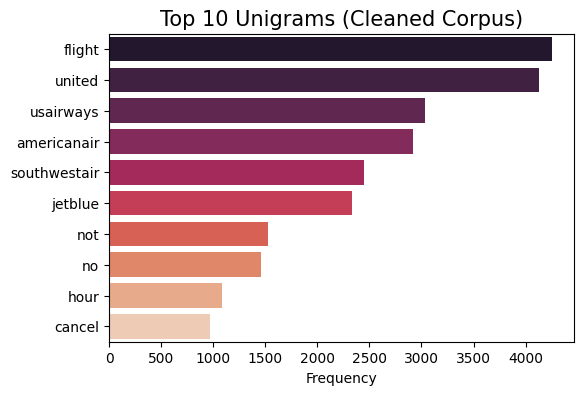

In [53]:
#Plotting Top 10 final cleaned corpus Unigrams
words, counts = zip(*top_unigrams_clean)
plt.figure(figsize=(6, 4))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False)
plt.title("Top 10 Unigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

##### Visualizing Top 10 Bigrams for till now cleaned corpus

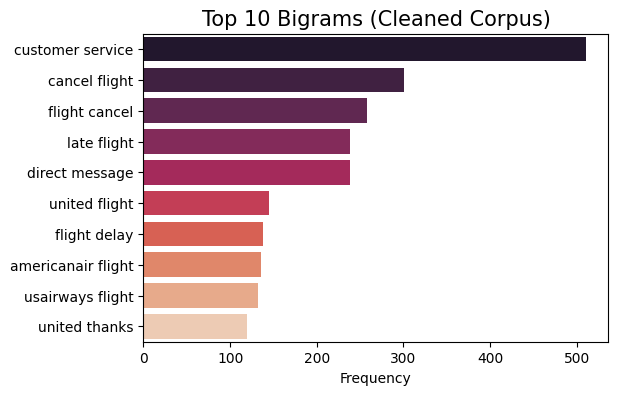

In [54]:
#Plotting Top 10 final cleaned corpus Bigrams
words, counts = zip(*top_bigrams_clean)
plt.figure(figsize=(6, 4))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False)
plt.title("Top 10 Bigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

##### Visualizing Top 10 Trigrams for till now cleaned corpus

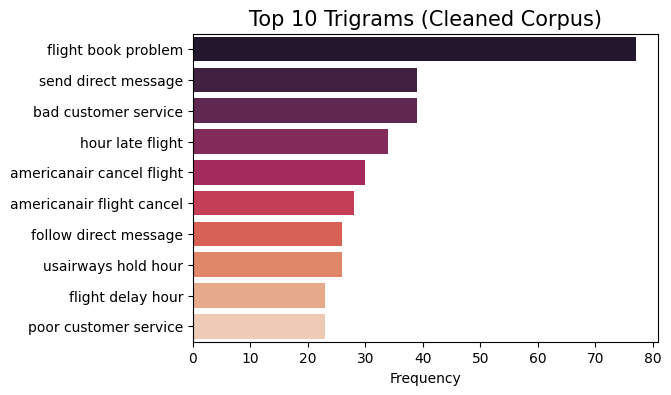

In [55]:
#Plotting Top 10 final cleaned corpus Trigrams
words, counts = zip(*top_trigrams_clean)
plt.figure(figsize=(6, 4))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False)
plt.title("Top 10 Trigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

##### Wordcloud for till now cleaned corpus

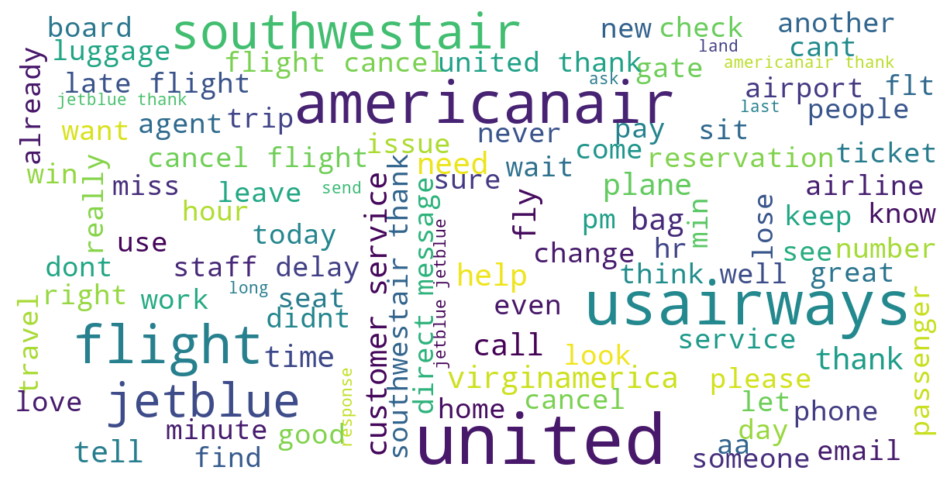

In [56]:
from wordcloud import WordCloud, STOPWORDS as workcloud_stopwords

def show_wordcloud(data):
    #Combining the list of strings into one single string (if it not already)
    if isinstance(data, pd.Series):
        text = ' '.join(data.astype(str))
    elif isinstance(data, list):
        text = ' '.join(data)
    else:
        text = str(data)

    #Configuring the WordCloud
    wordcloud = WordCloud(
        background_color='white',
        stopwords=workcloud_stopwords,
        max_words=100,
        max_font_size=30,
        scale=3,
        random_state=1
    )

    #Generating the word cloud
    wordcloud.generate(text)

    #Plotting the image
    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')
    plt.imshow(wordcloud, interpolation='bilinear') 
    plt.show()

#Calling the function with the corpus
show_wordcloud(corpus)

###### Dropping not needed any more columns in dataframe

In [57]:
df_text_tweets.drop(["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text",
                     "after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text",
                    "after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text",
                     "lemmatized_cleaned_text"
                    ],axis=1, inplace=True, errors='ignore')

#Checking at the moment columns
display(df_text_tweets.head())
#print(' ')
#display(df_text_tweets.sample(5))
#print(' ')
#display(df_text_tweets.tail())

,text,lemmatized_cleaned_text_final
0,@VirginAmerica What @dhepburn said.,virginamerica
1,@VirginAmerica plus you've added commercials to the experience... tacky.,virginamerica plus youve added commercial experience
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,virginamerica didnt today must mean need another
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",virginamerica really aggressive blast obnoxious entertainment guest little recourse
4,@VirginAmerica and it's a really big bad thing about it,virginamerica really big bad thing


###### Re-aligning final corpus with the original labels 

In [58]:
#Keeping only rows where the cleaned text of column "lemmatized_cleaned_text_final" has length greater than 0
df_text_tweets = df_text_tweets[df_text_tweets["lemmatized_cleaned_text_final"].str.strip() != ""]

#Final rows after removing empty rows in the cleaned text column "lemmatized_cleaned_text_final"
print(f"Rows after removing empty rows in finally cleaned text column: {len(df_text_tweets)}")

#Checking that both dataframes have the same index
print(f"full_df_tweets shape: {full_df_tweets.shape}")
print(f"df_text_tweets shape: {df_text_tweets.shape}")

#Re-aligning with the original labels via connection with indexes. With dropna ensuring indexes are aligned
df_final = pd.DataFrame({
    "text": df_text_tweets["lemmatized_cleaned_text_final"],  #final_corpus
    "airline_sentiment": full_df_tweets["airline_sentiment"], #labels
    "airline": full_df_tweets["airline"]                      #airline_names
}).dropna()

print(f"Model dataframe shape: {df_final.shape}")
print(f"Label distribution:\n{df_final['airline_sentiment'].value_counts()}")
print(f"Label distribution (%):\n{df_final['airline_sentiment'].value_counts(normalize=True).round(3)*100}")

#Verifying the alignment with the original labels 
print(f"Sample check:")
display(df_final.head())

#Updating corpus
corpus=df_final["text"]

#display(df_final.head())

Rows after removing empty rows in finally cleaned text column: 14586
full_df_tweets shape: (14587, 9)
df_text_tweets shape: (14586, 2)
Model dataframe shape: (14586, 3)
Label distribution:
airline_sentiment
negative    9152
neutral     3086
positive    2348
Name: count, dtype: int64
Label distribution (%):
airline_sentiment
negative    62.7
neutral     21.2
positive    16.1
Name: proportion, dtype: float64
Sample check:


,text,airline_sentiment,airline
0,virginamerica,neutral,Virgin America
1,virginamerica plus youve added commercial experience,positive,Virgin America
2,virginamerica didnt today must mean need another,neutral,Virgin America
3,virginamerica really aggressive blast obnoxious entertainment guest little recourse,negative,Virgin America
4,virginamerica really big bad thing,negative,Virgin America


###### Visualizing updated distribution of tweet word count

Mean Word Count: 8.00
Median Word Count: 9.00


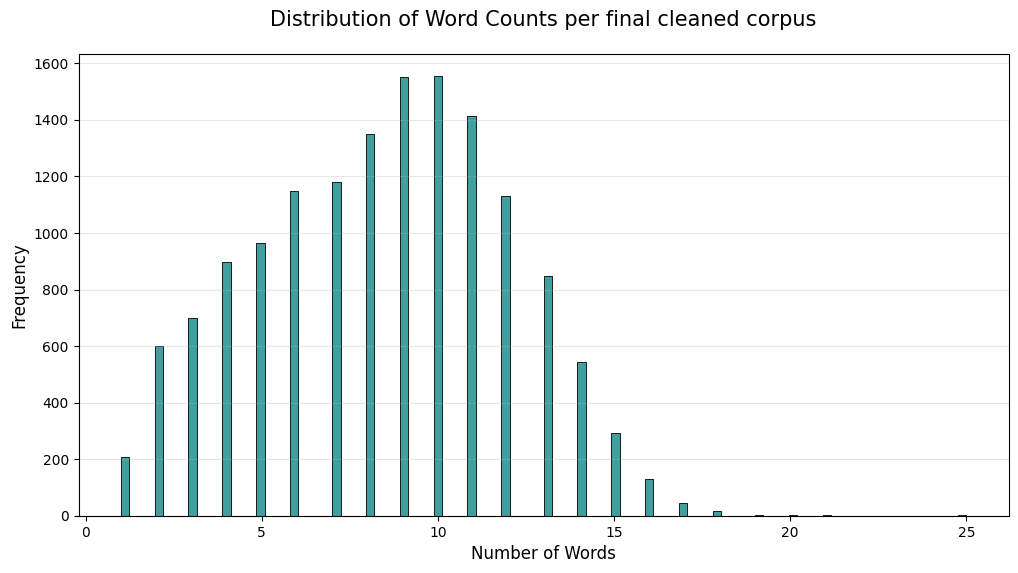

In [59]:
#Calculating updated word counts by splitting strings into lists
df_final["word_count"] = df_final["text"].str.split().str.len()

#Calculating key statistics
mean_words = df_final["word_count"].mean().round()
median_words = df_final["word_count"].median().round()

print(f"Mean Word Count: {mean_words:.2f}")
print(f"Median Word Count: {median_words:.2f}")

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_final["word_count"], bins=100, color="teal", label="Word Count")

plt.title("Distribution of Word Counts per final cleaned corpus", fontsize=15, pad=20)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

###### Visualizing updated Distribution of tweet character count 

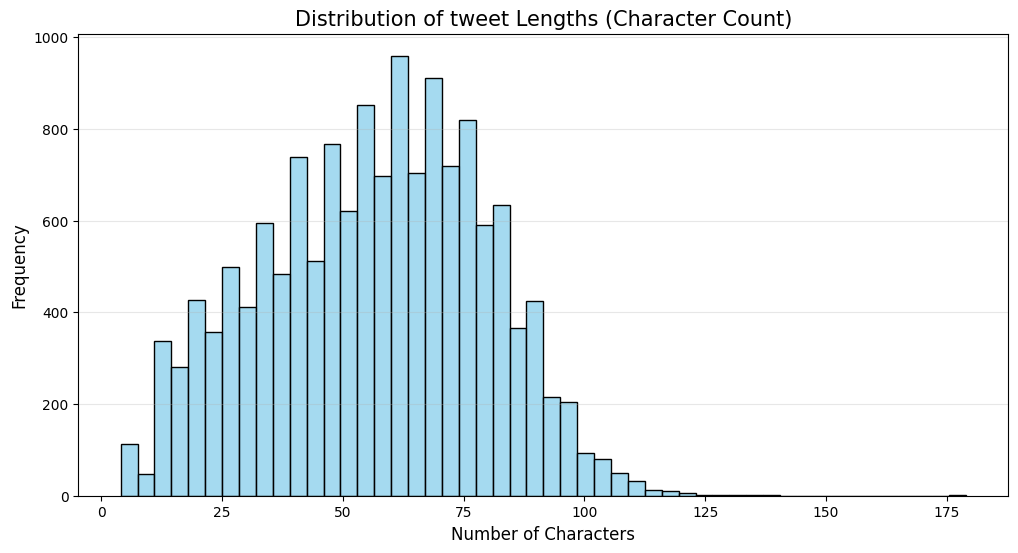

In [60]:
#Checking the number of characters present in each sentence to have a rough idea about the tweet text length
df_final["char_count"] = df_final["text"].str.len()

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_final["char_count"], bins=50, color="skyblue")
plt.title("Distribution of tweet Lengths (Character Count)", fontsize=15)
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

###### Visualizing updated average word tweet length 

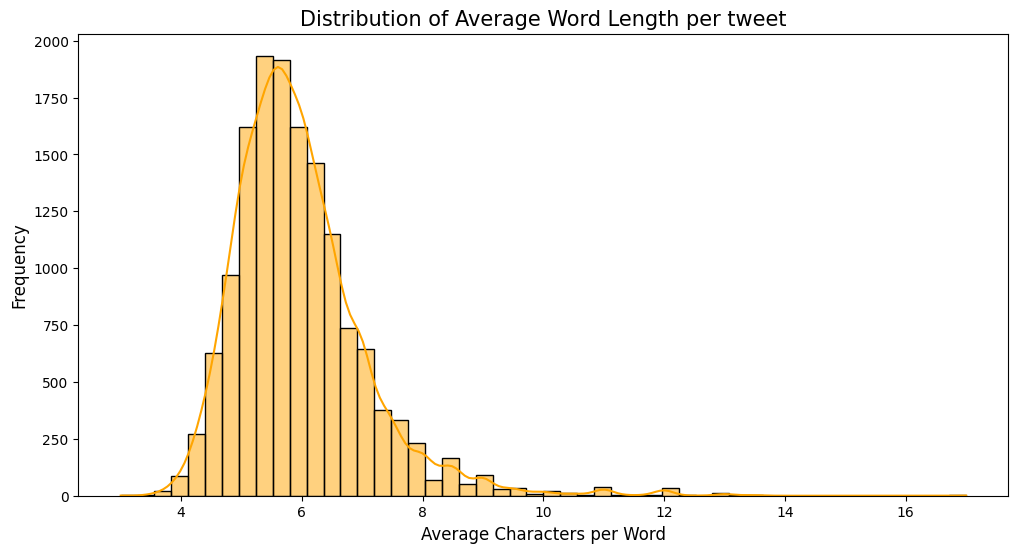

In [61]:
def get_avg_word_len(text):
    """Function to calculating average word length"""
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

df_final['avg_word_len'] = df_final['text'].apply(get_avg_word_len)

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_final['avg_word_len'], bins=50, kde=True, color="orange")

plt.title("Distribution of Average Word Length per tweet", fontsize=15)
plt.xlabel("Average Characters per Word", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

###### Topic Modelling for final cleaned corpus

In [62]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model

#Grabbing latest cleaned corpus
corpus = df_final["text"]

#Re-vectorizing the text 
tf_vectorizer = CountVectorizer(stop_words=None,
                                max_df=0.85,    #Ignoring words that appear in >85% of documents
                                min_df=2)       #Ignoring words that appear in less than 2 documents
    
tf = tf_vectorizer.fit_transform(corpus)

#Initializing and fitting the LDA model for 3 topics(one per sentiment) 
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(tf)

#Preparing the visualization
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda_model, tf, tf_vectorizer, mds='tsne')

#Printing top 10 words per topic
feature_names = tf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

#Displaying the dashboard
pyLDAvis.display(panel)

Topic 1: flight, americanair, united, southwestair, usairways, cancel, call, not, no, help
Topic 2: jetblue, southwestair, virginamerica, flight, seat, united, thank, not, thanks, americanair
Topic 3: united, usairways, flight, americanair, hour, delay, no, wait, time, service


##### LDA Topic Modelling Conclusions :

- Topic 1: flight, americanair, united, southwestair, usairways, cancel, call, not, no, help => Complaints & Service Requests
  Mapped sentiment: Negative
  
- Topic 2: jetblue, southwestair, virginamerica, flight, seat, united, thank, not, thanks, americanair => Positive/Neutral Experiences
  Mapped sentiment: Positive/Neutral

- Topic 3: united, usairways, flight, americanair, hour, delay, no, wait, time, service => Delays & operational issues
  Mapped sentiment: Negative/Neutral


##### Insight: 

- The 3 LDA topics align naturally with the 3 sentiment labels (positive,neutral,negative), confirming the validity of the sentiment classification task.

***

#### Feature Extraction (Vectorization)

***

#### ANN Classifier